<a href="https://colab.research.google.com/github/bangaru01/C_programing/blob/main/NatSyn_Visulization_Descriptors_maps.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## STEP 1 — Setup, read structures, and identify NN/NO/NS

In [1]:
# ============================================================
# STEP 1
# NN / NO / NS STRUCTURAL-VISUALIZATION WORKFLOW
# Setup + read XYZ structures
# ============================================================

!pip -q install morfeus-ml numpy pandas scipy matplotlib

from google.colab import drive
drive.mount("/content/drive")

import os
import re
import glob
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.spatial.transform import Rotation

from morfeus import (
    BuriedVolume,
    Sterimol,
    SolidAngle,
    Pyramidalization,
    read_xyz,
)


# ============================================================
# USER PATHS
# ============================================================

XYZ_FOLDER = "/content/drive/MyDrive/Nat_Syn-DM"

OUTPUT_FOLDER = (
    "/content/drive/MyDrive/"
    "Nat_Syn_DM_NN_NO_NS_Visualizations"
)

os.makedirs(OUTPUT_FOLDER, exist_ok=True)


# Individual output folders
GEOMETRY_FOLDER = os.path.join(
    OUTPUT_FOLDER,
    "01_Coordination_Geometry"
)

VBUR_FOLDER = os.path.join(
    OUTPUT_FOLDER,
    "02_Buried_Volume"
)

QUADRANT_FOLDER = os.path.join(
    OUTPUT_FOLDER,
    "03_Quadrant_Maps"
)

DONOR_PATH_FOLDER = os.path.join(
    OUTPUT_FOLDER,
    "04_Donor_Framework"
)

DISTAL_FOLDER = os.path.join(
    OUTPUT_FOLDER,
    "05_Distal_Sterics"
)

STERIMOL_FOLDER = os.path.join(
    OUTPUT_FOLDER,
    "06_Sterimol"
)

SOLID_ANGLE_FOLDER = os.path.join(
    OUTPUT_FOLDER,
    "07_Solid_Angle"
)

for folder in [
    GEOMETRY_FOLDER,
    VBUR_FOLDER,
    QUADRANT_FOLDER,
    DONOR_PATH_FOLDER,
    DISTAL_FOLDER,
    STERIMOL_FOLDER,
    SOLID_ANGLE_FOLDER,
]:
    os.makedirs(folder, exist_ok=True)


# ============================================================
# ATOM NUMBERING
# ============================================================

PD_ATOM = 1

SUBSTRATE_START = 2
SUBSTRATE_END = 19

LIGAND_START = 20


# ============================================================
# LIGAND CLASSES
# ============================================================

LIGAND_CLASSES = {

    # NN
    "L10": "NN",
    "L12": "NN",
    "L13": "NN",
    "L14": "NN",
    "L18": "NN",
    "L19": "NN",

    # NO
    "L11": "NO",
    "L15": "NO",
    "L16": "NO",
    "L17": "NO",

    # NS
    "L20": "NS",
    "L21": "NS",
    "L22": "NS",
    "L23": "NS",
    "L24": "NS",
    "L25": "NS",
}

# L26 intentionally excluded from this NN/NO/NS comparison
# because it is N/pi coordinated.


# ============================================================
# YIELD DATA
# ============================================================

YIELD_DATA = {
    "L10": 0,
    "L11": 1,
    "L12": 7,
    "L13": 0,
    "L14": 0,
    "L15": 0,
    "L16": 0,
    "L17": 0,
    "L18": 0,
    "L19": 25,
    "L20": 70,
    "L21": 64,
    "L22": 57,
    "L23": 55,
    "L24": 50,
    "L25": 9,
}


# ============================================================
# ELEMENT NORMALIZATION
# ============================================================

def normalize_element(element):
    element = str(element).strip()

    if len(element) == 1:
        return element.upper()

    return (
        element[0].upper()
        + element[1:].lower()
    )


# ============================================================
# CLEAN LIGAND NAME
# ============================================================

def clean_ligand_name(filepath):

    filename = os.path.basename(filepath)

    match = re.search(
        r"(L\d+)",
        filename,
        flags=re.IGNORECASE,
    )

    if match:
        return match.group(1).upper()

    return os.path.splitext(filename)[0]


# ============================================================
# SIMPLE XYZ READER
# ============================================================

def read_xyz_file(filepath):

    with open(filepath, "r") as file:
        lines = file.readlines()

    number_atoms = int(
        lines[0].strip()
    )

    elements = []
    coordinates = []

    for line in lines[2:2 + number_atoms]:

        parts = line.split()

        if len(parts) < 4:
            continue

        elements.append(
            normalize_element(parts[0])
        )

        coordinates.append([
            float(parts[1]),
            float(parts[2]),
            float(parts[3]),
        ])

    return (
        np.array(elements),
        np.array(
            coordinates,
            dtype=float,
        ),
    )


# ============================================================
# DISTANCE
# ============================================================

def distance(coord1, coord2):

    return float(
        np.linalg.norm(
            np.asarray(coord1)
            - np.asarray(coord2)
        )
    )


# ============================================================
# FIND XYZ FILES
# ============================================================

xyz_files = sorted(
    glob.glob(
        os.path.join(
            XYZ_FOLDER,
            "*.xyz",
        )
    )
)


print("=" * 80)
print("XYZ FILES FOUND")
print("=" * 80)

for filepath in xyz_files:

    ligand = clean_ligand_name(filepath)

    if ligand not in LIGAND_CLASSES:
        continue

    print(
        ligand,
        LIGAND_CLASSES[ligand],
        os.path.basename(filepath),
    )

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.0/101.0 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 4.9 MB/s eta 0:00:00
Mounted at /content/drive
XYZ FILES FOUND
L10 NN L10.xyz
L11 NO L11.xyz
L12 NN L12.xyz
L13 NN L13.xyz
L14 NN L14.xyz
L15 NO L15.xyz
L16 NO L16.xyz
L17 NO L17.xyz
L18 NN L18.xyz
L19 NN L19.xyz
L20 NS L20.xyz
L21 NS L21.xyz
L22 NS L22.xyz
L23 NS L23.xyz
L24 NS L24.xyz
L25 NS L25.xyz


## STEP 2 — Automatically identify Pd donor atoms

In [2]:
# ============================================================
# STEP 2
# IDENTIFY Pd DONORS
# ============================================================

DONOR_DISTANCE_WINDOWS = {

    "N": (1.90, 2.40),

    "O": (1.90, 2.40),

    "S": (2.25, 2.75),
}


def find_pd_donors(
    elements,
    coordinates,
):

    pd_index = PD_ATOM - 1

    pd_coord = coordinates[pd_index]

    candidates = []

    # Search ligand atoms only
    for atom_number in range(
        LIGAND_START,
        len(elements) + 1,
    ):

        element = elements[
            atom_number - 1
        ]

        if element not in [
            "N",
            "O",
            "S",
        ]:
            continue

        current_distance = distance(
            pd_coord,
            coordinates[
                atom_number - 1
            ],
        )

        lower, upper = (
            DONOR_DISTANCE_WINDOWS[element]
        )

        if lower <= current_distance <= upper:

            candidates.append({
                "Atom": atom_number,
                "Element": element,
                "Distance": current_distance,
            })

    candidates = sorted(
        candidates,
        key=lambda x: x["Distance"],
    )

    return candidates

In [3]:
# ============================================================
# EXPECTED DONOR PAIRS
# ============================================================

EXPECTED_DONORS = {
    "NN": ["N", "N"],
    "NO": ["N", "O"],
    "NS": ["N", "S"],
}


def select_donor_pair(
    ligand_class,
    candidates,
):

    expected = sorted(
        EXPECTED_DONORS[
            ligand_class
        ]
    )

    # Try every pair
    for i in range(
        len(candidates)
    ):

        for j in range(
            i + 1,
            len(candidates)
        ):

            pair = [
                candidates[i],
                candidates[j],
            ]

            elements_pair = sorted([
                pair[0]["Element"],
                pair[1]["Element"],
            ])

            if elements_pair == expected:

                return pair

    return None

In [4]:
donor_records = []


for filepath in xyz_files:

    ligand = clean_ligand_name(
        filepath
    )

    if ligand not in LIGAND_CLASSES:
        continue

    ligand_class = (
        LIGAND_CLASSES[ligand]
    )

    elements, coordinates = (
        read_xyz_file(filepath)
    )

    candidates = find_pd_donors(
        elements,
        coordinates,
    )

    pair = select_donor_pair(
        ligand_class,
        candidates,
    )

    if pair is None:

        print(
            "WARNING:",
            ligand,
            "donor pair not found",
        )

        continue

    donor_records.append({

        "Ligand": ligand,

        "Class": ligand_class,

        "Donor1Atom":
            pair[0]["Atom"],

        "Donor1Element":
            pair[0]["Element"],

        "Pd_Donor1":
            pair[0]["Distance"],

        "Donor2Atom":
            pair[1]["Atom"],

        "Donor2Element":
            pair[1]["Element"],

        "Pd_Donor2":
            pair[1]["Distance"],
    })


donor_df = pd.DataFrame(
    donor_records
)


display(donor_df)

,Ligand,Class,Donor1Atom,Donor1Element,Pd_Donor1,Donor2Atom,Donor2Element,Pd_Donor2
0,L10,NN,20,N,2.106736,23,N,2.218469
1,L11,NO,20,N,2.114977,24,O,2.311206
2,L12,NN,20,N,2.100926,24,N,2.168497
3,L13,NN,20,N,2.112562,23,N,2.126745
4,L14,NN,20,N,2.120567,23,N,2.286403
5,L15,NO,20,N,2.093161,24,O,2.377335
6,L16,NO,20,N,2.089185,24,O,2.384998
7,L18,NN,20,N,2.104112,24,N,2.274664
8,L20,NS,20,N,2.096311,24,S,2.540380
9,L21,NS,20,N,2.098302,24,S,2.525913


## STEP 3 — Calculate the coordination geometry used in the pictures

In [5]:
# ============================================================
# STEP 3
# COORDINATION GEOMETRY
# ============================================================

def angle_three_atoms(
    coord1,
    vertex,
    coord2,
):

    vector1 = (
        np.asarray(coord1)
        - np.asarray(vertex)
    )

    vector2 = (
        np.asarray(coord2)
        - np.asarray(vertex)
    )

    vector1 /= np.linalg.norm(
        vector1
    )

    vector2 /= np.linalg.norm(
        vector2
    )

    cosine = np.clip(
        np.dot(
            vector1,
            vector2,
        ),
        -1.0,
        1.0,
    )

    return float(
        np.degrees(
            np.arccos(cosine)
        )
    )

In [6]:
geometry_records = []


for filepath in xyz_files:

    ligand = clean_ligand_name(
        filepath
    )

    if ligand not in LIGAND_CLASSES:
        continue

    ligand_class = (
        LIGAND_CLASSES[ligand]
    )

    elements, coordinates = (
        read_xyz_file(filepath)
    )

    candidates = find_pd_donors(
        elements,
        coordinates,
    )

    pair = select_donor_pair(
        ligand_class,
        candidates,
    )

    if pair is None:
        continue

    donor1 = pair[0]["Atom"]
    donor2 = pair[1]["Atom"]

    pd_coord = coordinates[
        PD_ATOM - 1
    ]

    d1_coord = coordinates[
        donor1 - 1
    ]

    d2_coord = coordinates[
        donor2 - 1
    ]

    pd_d1 = distance(
        pd_coord,
        d1_coord,
    )

    pd_d2 = distance(
        pd_coord,
        d2_coord,
    )

    donor_distance = distance(
        d1_coord,
        d2_coord,
    )

    bite_angle = angle_three_atoms(
        d1_coord,
        pd_coord,
        d2_coord,
    )

    delta_pd = abs(
        pd_d1 - pd_d2
    )

    geometry_records.append({

        "Ligand": ligand,
        "Class": ligand_class,
        "Yield": YIELD_DATA[ligand],

        "Donor1":
            f"{pair[0]['Element']}{donor1}",

        "Donor2":
            f"{pair[1]['Element']}{donor2}",

        "Pd_D1_A":
            pd_d1,

        "Pd_D2_A":
            pd_d2,

        "Delta_Pd_Donor_A":
            delta_pd,

        "D1_D2_A":
            donor_distance,

        "BiteAngle_deg":
            bite_angle,
    })


geometry_df = pd.DataFrame(
    geometry_records
)


display(
    geometry_df.round(3)
)

,Ligand,Class,Yield,Donor1,Donor2,Pd_D1_A,Pd_D2_A,Delta_Pd_Donor_A,D1_D2_A,BiteAngle_deg
0,L10,NN,0,N20,N23,2.107,2.218,0.112,2.643,75.300
1,L11,NO,1,N20,O24,2.115,2.311,0.196,2.857,80.278
2,L12,NN,7,N20,N24,2.101,2.168,0.068,2.876,84.688
3,L13,NN,0,N20,N23,2.113,2.127,0.014,2.649,77.331
4,L14,NN,0,N20,N23,2.121,2.286,0.166,2.697,75.362
5,L15,NO,0,N20,O24,2.093,2.377,0.284,2.828,78.203
6,L16,NO,0,N20,O24,2.089,2.385,0.296,2.803,77.266
7,L18,NN,0,N20,N24,2.104,2.275,0.171,2.810,79.735
8,L20,NS,70,N20,S24,2.096,2.540,0.444,3.010,80.340
9,L21,NS,64,N20,S24,2.098,2.526,0.428,3.020,80.981


## STEP 4 — Put every complex into the SAME coordinate system

In [7]:
# ============================================================
# STEP 4
# COMMON Pd-CENTERED COORDINATE SYSTEM
# ============================================================

def normalize_vector(vector):

    vector = np.asarray(
        vector,
        dtype=float,
    )

    norm = np.linalg.norm(
        vector
    )

    if norm < 1e-12:
        raise ValueError(
            "Zero-length vector"
        )

    return vector / norm


def orient_pd_complex(
    coordinates,
    donor1,
    donor2,
):

    coords = np.array(
        coordinates,
        dtype=float,
    )

    # --------------------------------------------------------
    # 1. Translate Pd to origin
    # --------------------------------------------------------

    pd_coord = coords[
        PD_ATOM - 1
    ].copy()

    translated = (
        coords - pd_coord
    )

    d1 = translated[
        donor1 - 1
    ]

    d2 = translated[
        donor2 - 1
    ]

    # --------------------------------------------------------
    # 2. Y axis:
    # direction from Pd toward midpoint of donors
    # --------------------------------------------------------

    midpoint = (
        d1 + d2
    ) / 2.0

    y_axis = normalize_vector(
        midpoint
    )

    # --------------------------------------------------------
    # 3. X axis:
    # D1 -> D2 component perpendicular to Y
    # --------------------------------------------------------

    donor_vector = (
        d2 - d1
    )

    donor_vector_perpendicular = (
        donor_vector
        - np.dot(
            donor_vector,
            y_axis,
        ) * y_axis
    )

    x_axis = normalize_vector(
        donor_vector_perpendicular
    )

    # --------------------------------------------------------
    # 4. Z axis
    # --------------------------------------------------------

    z_axis = normalize_vector(
        np.cross(
            x_axis,
            y_axis,
        )
    )

    # Recalculate X for perfect orthogonality
    x_axis = normalize_vector(
        np.cross(
            y_axis,
            z_axis,
        )
    )

    rotation_matrix = np.vstack([
        x_axis,
        y_axis,
        z_axis,
    ])

    oriented = (
        rotation_matrix
        @ translated.T
    ).T

    return oriented

In [8]:
ORIENTED_FOLDER = os.path.join(
    OUTPUT_FOLDER,
    "00_Oriented_XYZ"
)

os.makedirs(
    ORIENTED_FOLDER,
    exist_ok=True,
)


def write_xyz(
    filepath,
    elements,
    coordinates,
    comment="",
):

    with open(
        filepath,
        "w",
    ) as file:

        file.write(
            f"{len(elements)}\n"
        )

        file.write(
            f"{comment}\n"
        )

        for element, xyz in zip(
            elements,
            coordinates,
        ):

            file.write(
                f"{element:<2s} "
                f"{xyz[0]:14.8f} "
                f"{xyz[1]:14.8f} "
                f"{xyz[2]:14.8f}\n"
            )

In [9]:
oriented_records = []


for filepath in xyz_files:

    ligand = clean_ligand_name(
        filepath
    )

    if ligand not in LIGAND_CLASSES:
        continue

    ligand_class = (
        LIGAND_CLASSES[ligand]
    )

    elements, coordinates = (
        read_xyz_file(filepath)
    )

    candidates = find_pd_donors(
        elements,
        coordinates,
    )

    pair = select_donor_pair(
        ligand_class,
        candidates,
    )

    if pair is None:
        continue

    donor1 = pair[0]["Atom"]
    donor2 = pair[1]["Atom"]

    oriented_coordinates = (
        orient_pd_complex(
            coordinates,
            donor1,
            donor2,
        )
    )

    output_xyz = os.path.join(
        ORIENTED_FOLDER,
        f"{ligand}_{ligand_class}_oriented.xyz",
    )

    write_xyz(
        output_xyz,
        elements,
        oriented_coordinates,
        comment=(
            f"{ligand} {ligand_class} "
            "Pd-centered common orientation"
        ),
    )

    oriented_records.append({
        "Ligand": ligand,
        "Class": ligand_class,
        "File": output_xyz,
        "Donor1": donor1,
        "Donor2": donor2,
    })


oriented_df = pd.DataFrame(
    oriented_records
)

display(oriented_df)

,Ligand,Class,File,Donor1,Donor2
0,L10,NN,/content/drive/MyDrive/Nat_Syn_DM_NN_NO_NS_Vis...,20,23
1,L11,NO,/content/drive/MyDrive/Nat_Syn_DM_NN_NO_NS_Vis...,20,24
2,L12,NN,/content/drive/MyDrive/Nat_Syn_DM_NN_NO_NS_Vis...,20,24
3,L13,NN,/content/drive/MyDrive/Nat_Syn_DM_NN_NO_NS_Vis...,20,23
4,L14,NN,/content/drive/MyDrive/Nat_Syn_DM_NN_NO_NS_Vis...,20,23
5,L15,NO,/content/drive/MyDrive/Nat_Syn_DM_NN_NO_NS_Vis...,20,24
6,L16,NO,/content/drive/MyDrive/Nat_Syn_DM_NN_NO_NS_Vis...,20,24
7,L18,NN,/content/drive/MyDrive/Nat_Syn_DM_NN_NO_NS_Vis...,20,24
8,L20,NS,/content/drive/MyDrive/Nat_Syn_DM_NN_NO_NS_Vis...,20,24
9,L21,NS,/content/drive/MyDrive/Nat_Syn_DM_NN_NO_NS_Vis...,20,24


## STEP 5 — Buried-volume maps

In [13]:
# ============================================================
# STEP 5 — CORRECTED
# MORFEUS BURIED VOLUME WITH DEFINED ORIENTATION
# ============================================================

from morfeus import BuriedVolume

VBUR_RADIUS = 5.5


def calculate_buried_volume(
    elements,
    coordinates,
    donor1,
    donor2,
):
    """
    Buried-volume calculation using the FULL Pd complex,
    but only ligand atoms contribute to buried volume.

    Orientation:
        metal_index   = Pd
        z_axis_atoms  = donor1 + donor2
        xz_plane_atoms = donor1

    This gives a reproducible donor-defined orientation
    for NN, NO and NS complexes.
    """

    # --------------------------------------------------------
    # Ligand atoms only are included in the steric calculation
    # --------------------------------------------------------

    ligand_atoms = list(
        range(
            LIGAND_START,
            len(elements) + 1
        )
    )

    # Everything except ligand atoms and Pd is excluded.
    excluded_atoms = [
        atom_number
        for atom_number in range(
            1,
            len(elements) + 1
        )
        if (
            atom_number != PD_ATOM
            and atom_number not in ligand_atoms
        )
    ]

    # --------------------------------------------------------
    # BuriedVolume
    # --------------------------------------------------------

    bv = BuriedVolume(
        elements,
        coordinates,

        metal_index=PD_ATOM,

        excluded_atoms=excluded_atoms,

        radius=VBUR_RADIUS,

        # Critical for steric-map orientation
        z_axis_atoms=[
            int(donor1),
            int(donor2),
        ],

        # fixes rotation around z
        xz_plane_atoms=[
            int(donor1)
        ],
    )

    return bv

In [14]:
# ============================================================
# CALCULATE %VBUR
# ============================================================

vbur_records = []


for _, row in oriented_df.iterrows():

    ligand = row["Ligand"]
    ligand_class = row["Class"]

    elements, coordinates = read_xyz_file(
        row["File"]
    )

    try:

        bv = calculate_buried_volume(
            elements=elements,
            coordinates=coordinates,
            donor1=int(row["Donor1"]),
            donor2=int(row["Donor2"]),
        )

        percent_vbur = (
            bv.fraction_buried_volume
            * 100.0
        )

        vbur_records.append({
            "Ligand": ligand,
            "Class": ligand_class,
            "%Vbur_5.5A": percent_vbur,
        })

        print(
            f"{ligand:4s} "
            f"{ligand_class:2s}   "
            f"%Vbur = {percent_vbur:7.2f}"
        )

    except Exception as error:

        print(
            f"VBUR ERROR: {ligand}: {error}"
        )


vbur_df = pd.DataFrame(
    vbur_records
)

display(
    vbur_df.round(3)
)

L10  NN   %Vbur =   23.26
L11  NO   %Vbur =   23.82
L12  NN   %Vbur =   28.48
L13  NN   %Vbur =   22.59
L14  NN   %Vbur =   25.29
L15  NO   %Vbur =   23.70
L16  NO   %Vbur =   26.51
L18  NN   %Vbur =   23.93
L20  NS   %Vbur =   28.36
L21  NS   %Vbur =   29.39
L22  NS   %Vbur =   31.56
L23  NS   %Vbur =   32.44
L24  NS   %Vbur =   29.32
L25  NS   %Vbur =   29.51


,Ligand,Class,%Vbur_5.5A
0,L10,NN,23.263
1,L11,NO,23.817
2,L12,NN,28.484
3,L13,NN,22.590
4,L14,NN,25.291
5,L15,NO,23.702
6,L16,NO,26.508
7,L18,NN,23.933
8,L20,NS,28.363
9,L21,NS,29.394


## STEP 6 — Generate the 2D steric maps

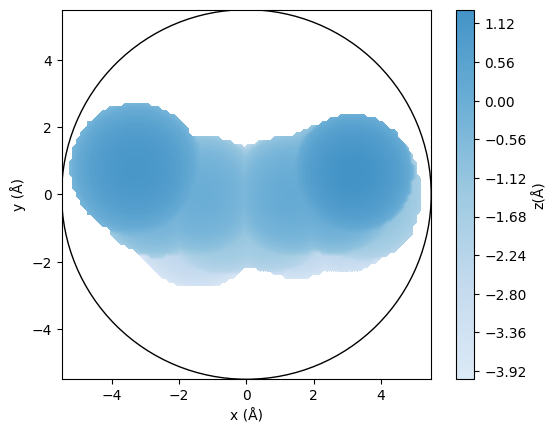


L10 (NN)   |   %Vbur (5.5 Å) = 23.26
NN ligand: N(primary) – N(secondary)   |   MAP COLOR = BLUE
Map displayed successfully; this Morfeus version closed its internal figure before manual saving.


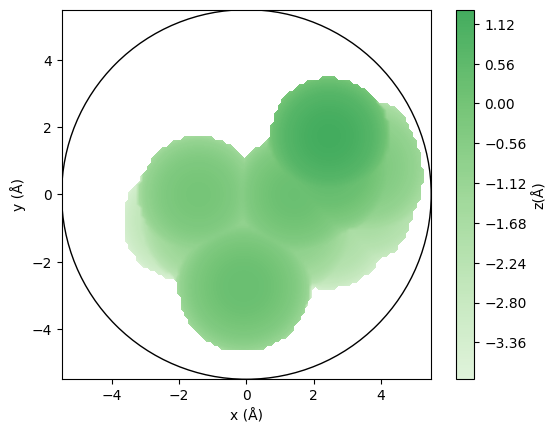


L11 (NO)   |   %Vbur (5.5 Å) = 23.82
NO ligand: N(primary) – O(secondary)   |   MAP COLOR = GREEN
Map displayed successfully; this Morfeus version closed its internal figure before manual saving.


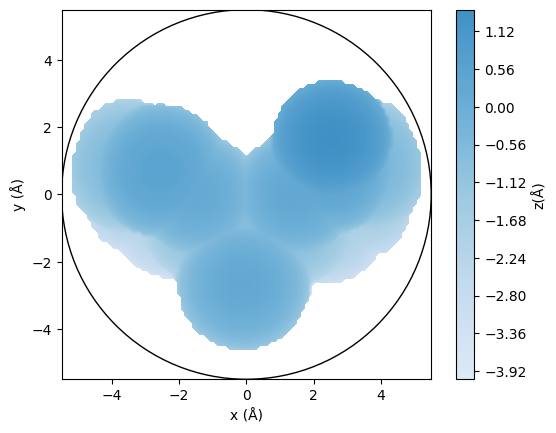


L12 (NN)   |   %Vbur (5.5 Å) = 28.48
NN ligand: N(primary) – N(secondary)   |   MAP COLOR = BLUE
Map displayed successfully; this Morfeus version closed its internal figure before manual saving.


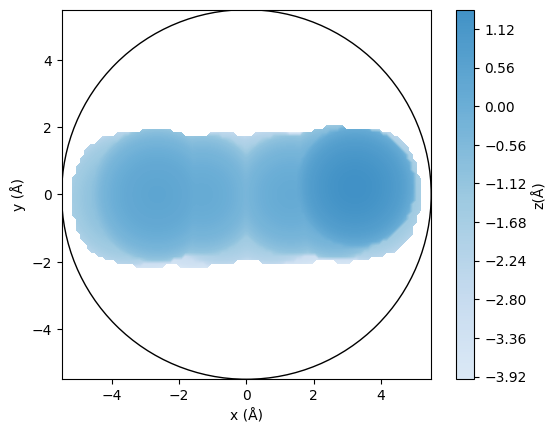


L13 (NN)   |   %Vbur (5.5 Å) = 22.59
NN ligand: N(primary) – N(secondary)   |   MAP COLOR = BLUE
Map displayed successfully; this Morfeus version closed its internal figure before manual saving.


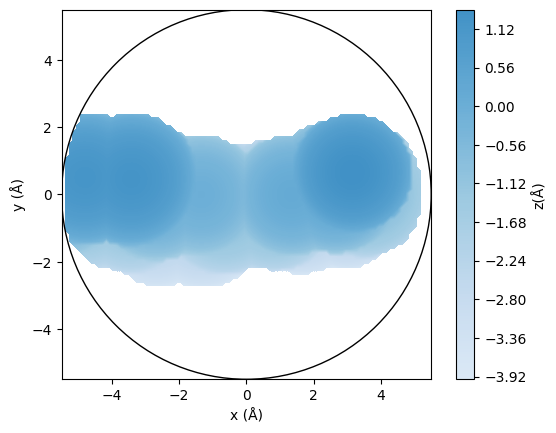


L14 (NN)   |   %Vbur (5.5 Å) = 25.29
NN ligand: N(primary) – N(secondary)   |   MAP COLOR = BLUE
Map displayed successfully; this Morfeus version closed its internal figure before manual saving.


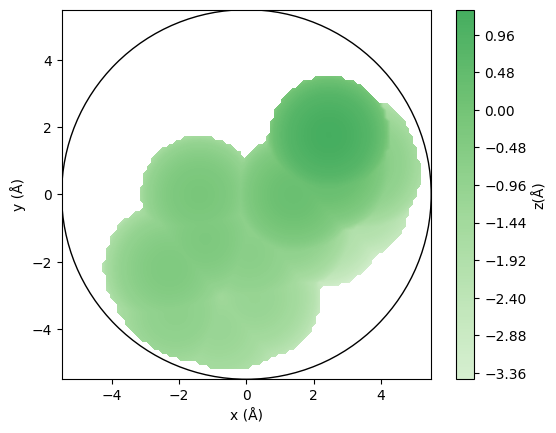


L15 (NO)   |   %Vbur (5.5 Å) = 23.70
NO ligand: N(primary) – O(secondary)   |   MAP COLOR = GREEN
Map displayed successfully; this Morfeus version closed its internal figure before manual saving.


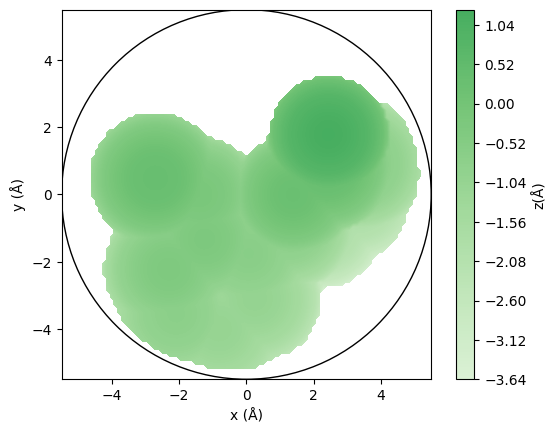


L16 (NO)   |   %Vbur (5.5 Å) = 26.51
NO ligand: N(primary) – O(secondary)   |   MAP COLOR = GREEN
Map displayed successfully; this Morfeus version closed its internal figure before manual saving.


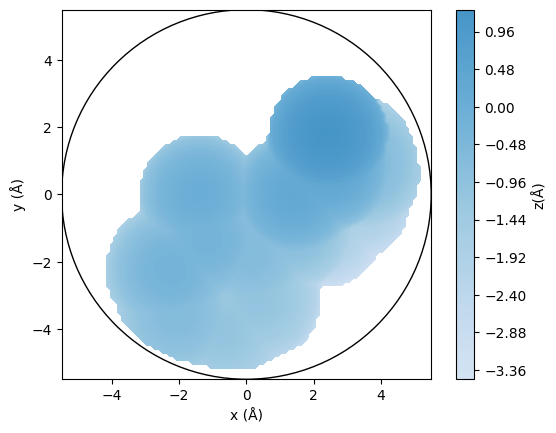


L18 (NN)   |   %Vbur (5.5 Å) = 23.93
NN ligand: N(primary) – N(secondary)   |   MAP COLOR = BLUE
Map displayed successfully; this Morfeus version closed its internal figure before manual saving.


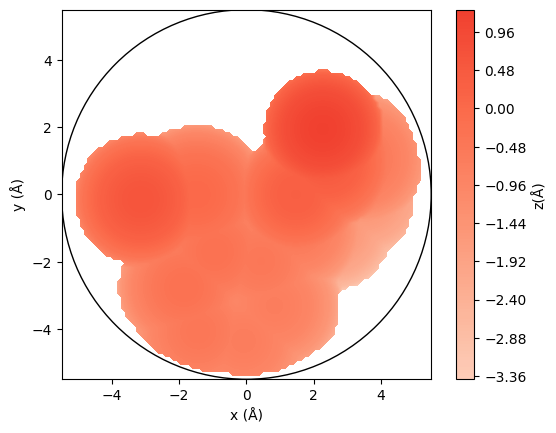


L20 (NS)   |   %Vbur (5.5 Å) = 28.36
NS ligand: N(primary) – S(secondary)   |   MAP COLOR = RED
Map displayed successfully; this Morfeus version closed its internal figure before manual saving.


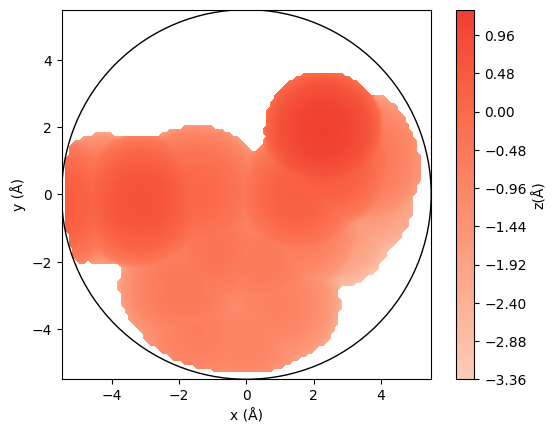


L21 (NS)   |   %Vbur (5.5 Å) = 29.39
NS ligand: N(primary) – S(secondary)   |   MAP COLOR = RED
Map displayed successfully; this Morfeus version closed its internal figure before manual saving.


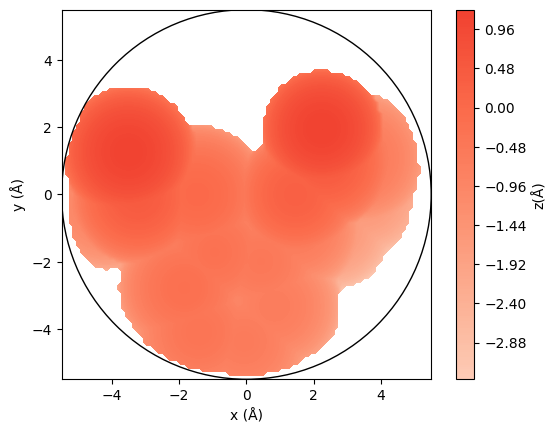


L22 (NS)   |   %Vbur (5.5 Å) = 31.56
NS ligand: N(primary) – S(secondary)   |   MAP COLOR = RED
Map displayed successfully; this Morfeus version closed its internal figure before manual saving.


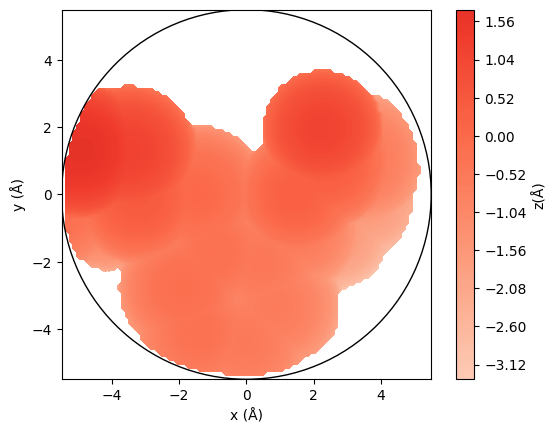


L23 (NS)   |   %Vbur (5.5 Å) = 32.44
NS ligand: N(primary) – S(secondary)   |   MAP COLOR = RED
Map displayed successfully; this Morfeus version closed its internal figure before manual saving.


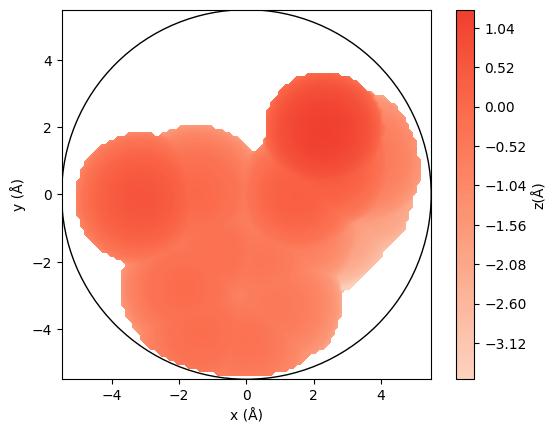


L24 (NS)   |   %Vbur (5.5 Å) = 29.32
NS ligand: N(primary) – S(secondary)   |   MAP COLOR = RED
Map displayed successfully; this Morfeus version closed its internal figure before manual saving.


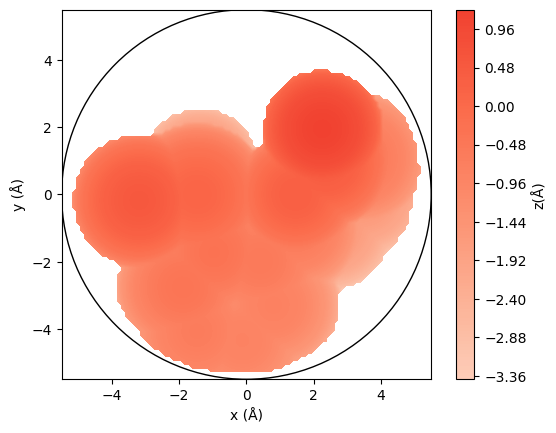


L25 (NS)   |   %Vbur (5.5 Å) = 29.51
NS ligand: N(primary) – S(secondary)   |   MAP COLOR = RED
Map displayed successfully; this Morfeus version closed its internal figure before manual saving.


In [18]:
# ============================================================
# STEP 6 — FINAL CLASS-COLORED STERIC MAPS
#
# NN → BLUE MAP
# NO → GREEN MAP
# NS → RED MAP
#
# No extra plt.figure()
# No plt.gca()
# No manual axis handling
# No blank figures
# ============================================================

import os
import matplotlib.pyplot as plt


# ============================================================
# CLASS-SPECIFIC COLORMAPS
# ============================================================

CLASS_CMAPS = {
    "NN": "Blues",
    "NO": "Greens",
    "NS": "Reds",
}


# ============================================================
# GENERATE MAPS
# ============================================================

for _, row in oriented_df.iterrows():

    ligand = row["Ligand"]
    ligand_class = row["Class"]

    elements, coordinates = read_xyz_file(
        row["File"]
    )

    try:

        # ----------------------------------------------------
        # 1. Calculate buried volume
        # ----------------------------------------------------

        bv = calculate_buried_volume(
            elements=elements,
            coordinates=coordinates,
            donor1=int(row["Donor1"]),
            donor2=int(row["Donor2"]),
        )

        percent_vbur = (
            bv.fraction_buried_volume
            * 100.0
        )


        # ----------------------------------------------------
        # 2. Choose map color according to ligand class
        # ----------------------------------------------------

        cmap = CLASS_CMAPS[
            ligand_class
        ]


        # ----------------------------------------------------
        # 3. Generate steric map
        #
        # IMPORTANT:
        # Morfeus handles its own figure.
        # ----------------------------------------------------

        bv.plot_steric_map(
            cmap=cmap
        )


        # ----------------------------------------------------
        # 4. Print identification immediately after map
        # ----------------------------------------------------

        print(
            "\n"
            + "=" * 65
        )

        print(
            f"{ligand} ({ligand_class})"
            f"   |   "
            f"%Vbur (5.5 Å) = {percent_vbur:.2f}"
        )

        if ligand_class == "NN":

            print(
                "NN ligand: "
                "N(primary) – N(secondary)"
                "   |   MAP COLOR = BLUE"
            )

        elif ligand_class == "NO":

            print(
                "NO ligand: "
                "N(primary) – O(secondary)"
                "   |   MAP COLOR = GREEN"
            )

        elif ligand_class == "NS":

            print(
                "NS ligand: "
                "N(primary) – S(secondary)"
                "   |   MAP COLOR = RED"
            )

        print(
            "=" * 65
        )


        # ----------------------------------------------------
        # 5. Save
        #
        # Depending on Morfeus version, the plotting function
        # may handle/display its own figure. Try current figure
        # only if it exists.
        # ----------------------------------------------------

        output_png = os.path.join(
            VBUR_FOLDER,
            f"{ligand}_{ligand_class}_"
            f"Vbur_5.5A_StericMap.png",
        )

        if plt.get_fignums():

            fig = plt.gcf()

            fig.savefig(
                output_png,
                dpi=600,
                bbox_inches="tight",
                facecolor="white",
            )

            plt.close(fig)

            print(
                "Saved:",
                output_png
            )

        else:

            print(
                "Map displayed successfully; "
                "this Morfeus version closed its "
                "internal figure before manual saving."
            )


    except Exception as error:

        plt.close("all")

        print(
            f"MAP ERROR: "
            f"{ligand}: "
            f"{error}"
        )

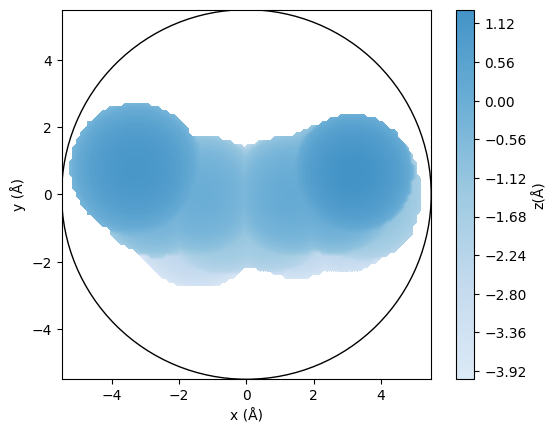

L10  | NN | secondary donor = N23 | %Vbur = 23.26


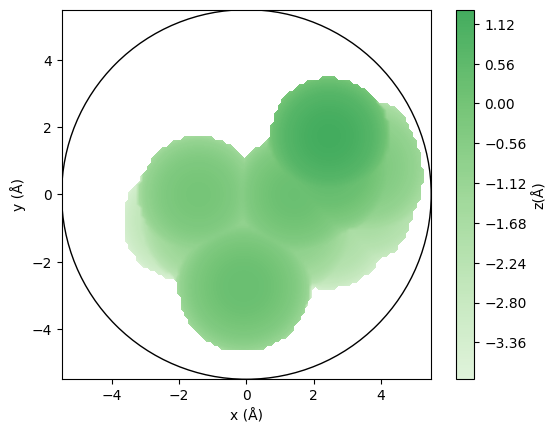

L11  | NO | secondary donor = O24 | %Vbur = 23.82


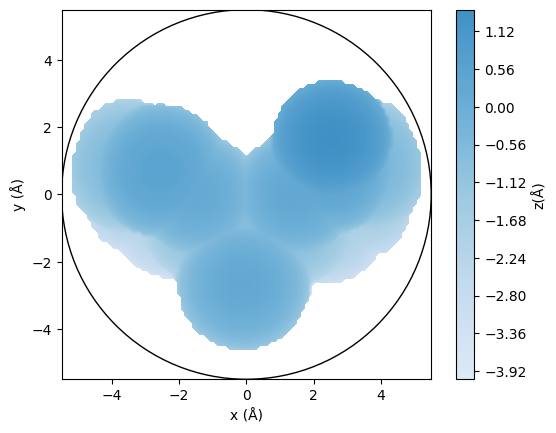

L12  | NN | secondary donor = N24 | %Vbur = 28.48


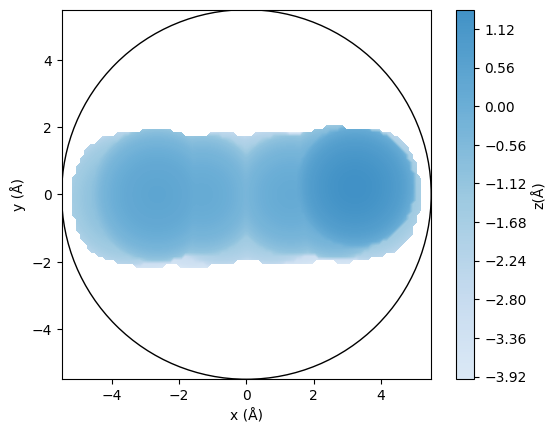

L13  | NN | secondary donor = N23 | %Vbur = 22.59


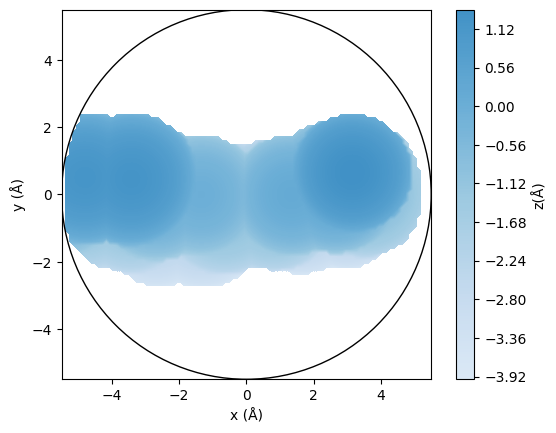

L14  | NN | secondary donor = N23 | %Vbur = 25.29


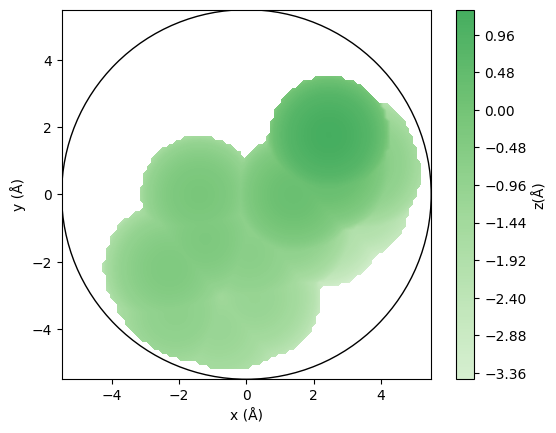

L15  | NO | secondary donor = O24 | %Vbur = 23.70


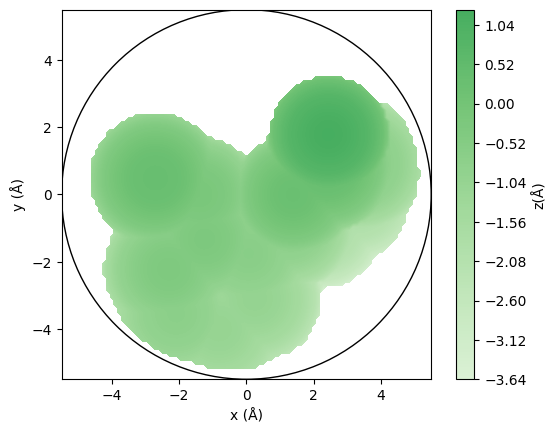

L16  | NO | secondary donor = O24 | %Vbur = 26.51


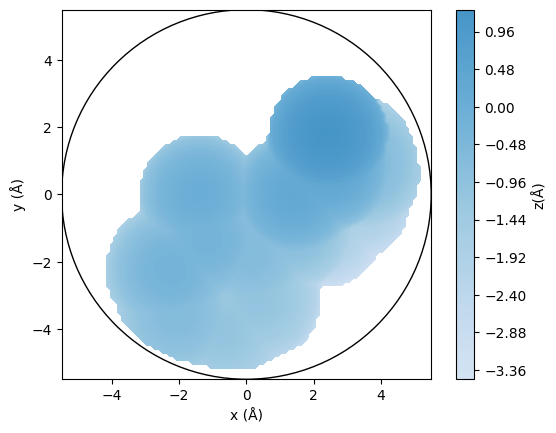

L18  | NN | secondary donor = N24 | %Vbur = 23.93


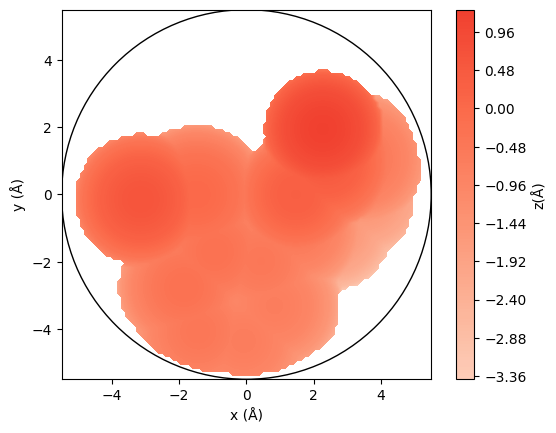

L20  | NS | secondary donor = S24 | %Vbur = 28.36


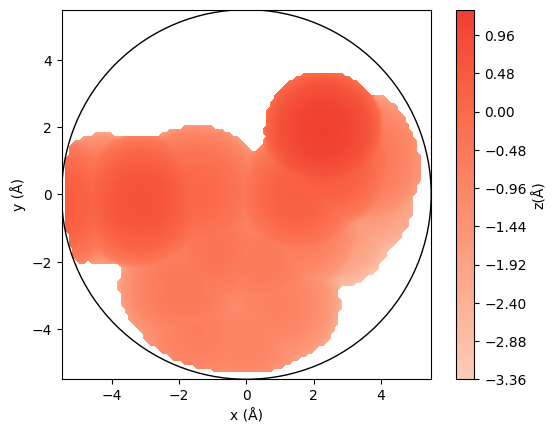

L21  | NS | secondary donor = S24 | %Vbur = 29.39


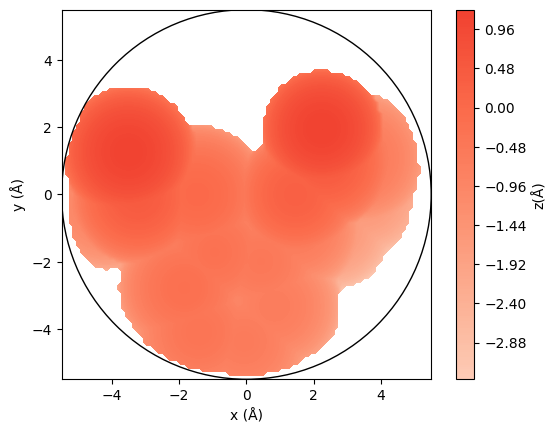

L22  | NS | secondary donor = S24 | %Vbur = 31.56


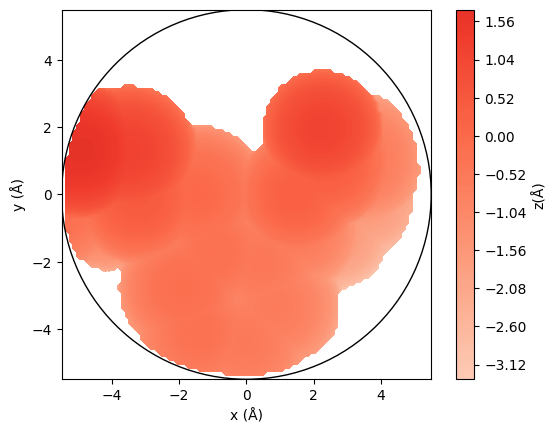

L23  | NS | secondary donor = S24 | %Vbur = 32.44


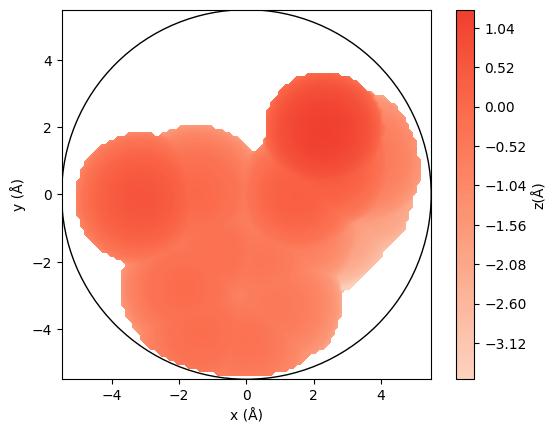

L24  | NS | secondary donor = S24 | %Vbur = 29.32


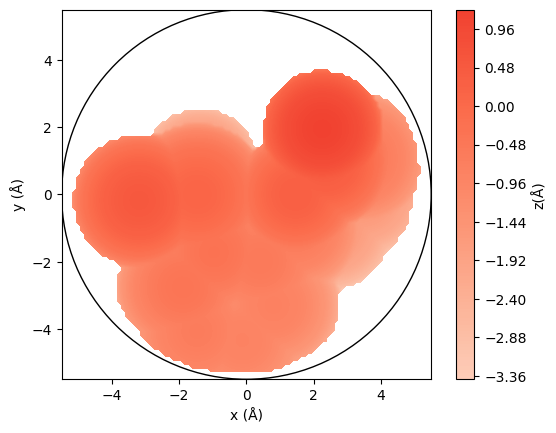

L25  | NS | secondary donor = S24 | %Vbur = 29.51


In [19]:
# ============================================================
# STEP 6 — DONOR-ANNOTATED BURIED-VOLUME MAPS
#
# Purpose:
#   1. Generate normal Morfeus buried-volume map
#   2. Explicitly show secondary donor position:
#          NN -> N
#          NO -> O
#          NS -> S
#   3. Show %Vbur prominently in bold
#
# IMPORTANT:
# The N/O/S marker identifies the projected donor position.
# It does NOT represent an atom-by-atom decomposition of %Vbur.
# ============================================================

import os
import matplotlib.pyplot as plt


# ============================================================
# 1. CLASS COLORMAPS
# ============================================================

CLASS_CMAPS = {
    "NN": "Blues",
    "NO": "Greens",
    "NS": "Reds",
}


# ============================================================
# 2. STANDARD ELEMENT COLORS FOR DONOR MARKERS
# ============================================================

DONOR_COLORS = {
    "N": "#3050F8",   # conventional nitrogen blue
    "O": "#FF0D0D",   # conventional oxygen red
    "S": "#FFD123",   # conventional sulfur yellow/gold
}


# ============================================================
# 3. EXPECTED SECONDARY DONOR
# ============================================================

SECONDARY_DONOR = {
    "NN": "N",
    "NO": "O",
    "NS": "S",
}


# ============================================================
# 4. FIND WHICH OF THE TWO DONORS IS THE SECONDARY DONOR
# ============================================================

def identify_secondary_donor(
    elements,
    donor1,
    donor2,
    ligand_class,
):
    """
    Returns:
        secondary_atom_number
        secondary_element

    NO -> O donor
    NS -> S donor

    NN is chemically ambiguous from element identity alone
    because both donors are N.

    For NN, this function currently assigns donor2.
    If your original descriptor workflow has a chemically
    defined primary/secondary N assignment, replace this
    with that exact atom assignment.
    """

    d1_element = elements[
        int(donor1) - 1
    ]

    d2_element = elements[
        int(donor2) - 1
    ]


    # --------------------------------------------------------
    # NO: secondary donor must be O
    # --------------------------------------------------------

    if ligand_class == "NO":

        if d1_element == "O":
            return int(donor1), "O"

        if d2_element == "O":
            return int(donor2), "O"

        raise ValueError(
            "NO ligand: O secondary donor not found."
        )


    # --------------------------------------------------------
    # NS: secondary donor must be S
    # --------------------------------------------------------

    elif ligand_class == "NS":

        if d1_element == "S":
            return int(donor1), "S"

        if d2_element == "S":
            return int(donor2), "S"

        raise ValueError(
            "NS ligand: S secondary donor not found."
        )


    # --------------------------------------------------------
    # NN: both atoms are N
    # --------------------------------------------------------

    elif ligand_class == "NN":

        if (
            d1_element == "N"
            and d2_element == "N"
        ):

            # IMPORTANT:
            # Both are nitrogen.
            #
            # We cannot chemically distinguish primary N
            # from secondary N based only on element type.
            #
            # For visualization we temporarily use donor2.
            # If your descriptor workflow defines which N
            # is secondary, use that atom instead.

            return int(donor2), "N"

        raise ValueError(
            "NN ligand: expected two N donors."
        )


    else:

        raise ValueError(
            f"Unknown ligand class: {ligand_class}"
        )


# ============================================================
# 5. GENERATE DONOR-ANNOTATED MAPS
# ============================================================

for _, row in oriented_df.iterrows():

    ligand = row["Ligand"]
    ligand_class = row["Class"]

    donor1 = int(
        row["Donor1"]
    )

    donor2 = int(
        row["Donor2"]
    )


    elements, coordinates = read_xyz_file(
        row["File"]
    )


    try:

        # ====================================================
        # A. CALCULATE BURIED VOLUME
        # ====================================================

        bv = calculate_buried_volume(
            elements=elements,
            coordinates=coordinates,
            donor1=donor1,
            donor2=donor2,
        )


        percent_vbur = (
            bv.fraction_buried_volume
            * 100.0
        )


        # ====================================================
        # B. IDENTIFY SECONDARY DONOR
        # ====================================================

        (
            secondary_atom,
            secondary_element,
        ) = identify_secondary_donor(
            elements=elements,
            donor1=donor1,
            donor2=donor2,
            ligand_class=ligand_class,
        )


        donor_color = DONOR_COLORS[
            secondary_element
        ]


        # ====================================================
        # C. GET SECONDARY-DONOR COORDINATES
        # ====================================================

        secondary_xyz = coordinates[
            secondary_atom - 1
        ]


        # ----------------------------------------------------
        # IMPORTANT
        #
        # Your oriented XYZ already uses a common Pd-centered
        # coordinate system.
        #
        # The Morfeus steric map is a 2D projection.
        # Here we use x/y of the oriented structure as the
        # projected donor location.
        # ----------------------------------------------------

        donor_x = secondary_xyz[0]
        donor_y = secondary_xyz[1]


        # ====================================================
        # D. SELECT CLASS COLORMAP
        # ====================================================

        cmap = CLASS_CMAPS[
            ligand_class
        ]


        # ====================================================
        # E. GENERATE MORFEUS MAP
        # ====================================================

        bv.plot_steric_map(
            cmap=cmap
        )


        # ====================================================
        # F. ACCESS CURRENT AXIS IF AVAILABLE
        #
        # Some Morfeus versions expose the current figure
        # differently. Therefore do not raise an error if
        # the figure is internally handled.
        # ====================================================

        if plt.get_fignums():

            fig = plt.gcf()

            axes = fig.get_axes()

            # Find the main plotting axis rather than
            # the colorbar axis.
            main_ax = None

            for candidate_ax in axes:

                # Main map normally has x and y labels.
                if (
                    candidate_ax.get_xlabel()
                    or candidate_ax.get_ylabel()
                ):
                    main_ax = candidate_ax
                    break


            if main_ax is None and len(axes) > 0:
                main_ax = axes[0]


            # =================================================
            # G. ADD SECONDARY DONOR MARKER
            # =================================================

            if main_ax is not None:

                main_ax.scatter(
                    donor_x,
                    donor_y,

                    s=260,

                    color=donor_color,

                    edgecolor="black",

                    linewidth=1.5,

                    zorder=30,
                )


                # ---------------------------------------------
                # Put element symbol inside marker
                # ---------------------------------------------

                text_color = (
                    "black"
                    if secondary_element == "S"
                    else "white"
                )


                main_ax.text(
                    donor_x,
                    donor_y,

                    secondary_element,

                    ha="center",
                    va="center",

                    fontsize=11,
                    fontweight="bold",

                    color=text_color,

                    zorder=31,
                )


                # =============================================
                # H. MAIN TITLE
                # =============================================

                main_ax.set_title(
                    f"{ligand} ({ligand_class})",
                    fontsize=14,
                    fontweight="bold",
                    pad=34,
                )


                # =============================================
                # I. BOLD %VBUR
                # =============================================

                main_ax.text(
                    0.50,
                    1.035,

                    f"%Vbur (5.5 Å) = "
                    f"{percent_vbur:.1f}",

                    transform=main_ax.transAxes,

                    ha="center",
                    va="bottom",

                    fontsize=13,
                    fontweight="bold",

                    color="black",

                    clip_on=False,
                )


                # =============================================
                # J. SECONDARY-DONOR LABEL
                # =============================================

                main_ax.text(
                    0.02,
                    0.98,

                    f"Secondary donor: "
                    f"{secondary_element}",

                    transform=main_ax.transAxes,

                    ha="left",
                    va="top",

                    fontsize=10,
                    fontweight="bold",

                    color=donor_color,

                    bbox={
                        "boxstyle":
                            "round,pad=0.25",

                        "facecolor":
                            "white",

                        "edgecolor":
                            donor_color,

                        "linewidth":
                            1.3,

                        "alpha":
                            0.92,
                    },

                    zorder=40,
                )


                # =============================================
                # K. SAVE
                # =============================================

                output_png = os.path.join(
                    VBUR_FOLDER,

                    f"{ligand}_"
                    f"{ligand_class}_"
                    f"Vbur_5.5A_"
                    f"DonorAnnotated.png",
                )


                fig.savefig(
                    output_png,

                    dpi=600,

                    bbox_inches="tight",

                    facecolor="white",
                )


                print(
                    f"{ligand:4s} | "
                    f"{ligand_class:2s} | "
                    f"secondary donor = "
                    f"{secondary_element}"
                    f"{secondary_atom} | "
                    f"%Vbur = "
                    f"{percent_vbur:.2f}"
                )


                plt.show()

                plt.close(fig)


        else:

            # Morfeus displayed/closed its own figure.
            #
            # We still print all calculated information,
            # but do not falsely report an annotation/save.

            print(
                f"{ligand:4s} | "
                f"{ligand_class:2s} | "
                f"secondary donor = "
                f"{secondary_element}"
                f"{secondary_atom} | "
                f"%Vbur = "
                f"{percent_vbur:.2f}"
            )


    except Exception as error:

        plt.close("all")

        print(
            f"MAP ERROR: "
            f"{ligand}: "
            f"{error}"
        )

In [20]:
# ============================================================
# DIAGNOSTIC — RUN FOR L10 ONLY
# Find the steric-map data available in your Morfeus version
# ============================================================

test_row = oriented_df[
    oriented_df["Ligand"] == "L10"
].iloc[0]

elements, coordinates = read_xyz_file(
    test_row["File"]
)

bv = calculate_buried_volume(
    elements=elements,
    coordinates=coordinates,
    donor1=int(test_row["Donor1"]),
    donor2=int(test_row["Donor2"]),
)

print("=" * 80)
print("MORFEUS BURIEDVOLUME ATTRIBUTES")
print("=" * 80)

for name in dir(bv):

    if not name.startswith("_"):

        try:
            value = getattr(bv, name)

            if isinstance(
                value,
                (
                    int,
                    float,
                    str,
                    list,
                    tuple,
                    dict,
                    np.ndarray,
                )
            ):

                if isinstance(
                    value,
                    np.ndarray
                ):

                    print(
                        f"{name:40s} "
                        f"ARRAY shape = {value.shape}"
                    )

                else:

                    text = str(value)

                    print(
                        f"{name:40s} "
                        f"{text[:150]}"
                    )

        except:
            pass

MORFEUS BURIEDVOLUME ATTRIBUTES
buried_volume                            162.12524631670865
fraction_buried_volume                   0.23263441939559987
free_volume                              534.784724004627
percent_buried_volume                    0.23263441939559987


/tmp/ipykernel_3998/2125052583.py:30: DeprecationWarning: 'percent_buried_volume' is deprecated. Use 'fraction_buried_volume'.
  value = getattr(bv, name)


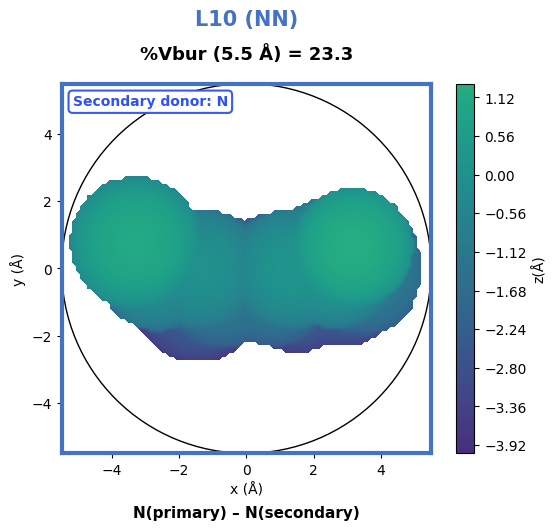

✓ L10  | NN | secondary donor = N23 | %Vbur = 23.26


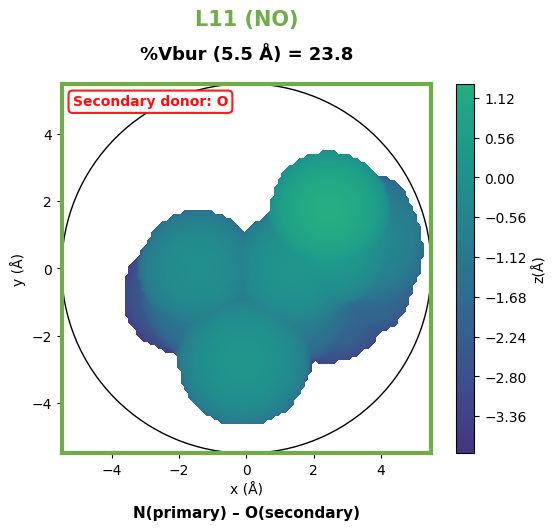

✓ L11  | NO | secondary donor = O24 | %Vbur = 23.82


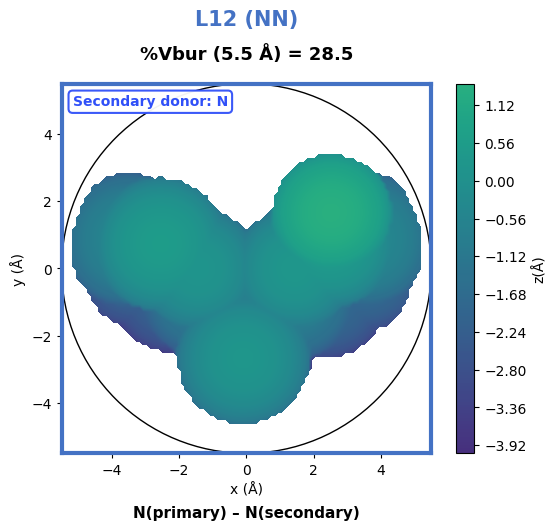

✓ L12  | NN | secondary donor = N24 | %Vbur = 28.48


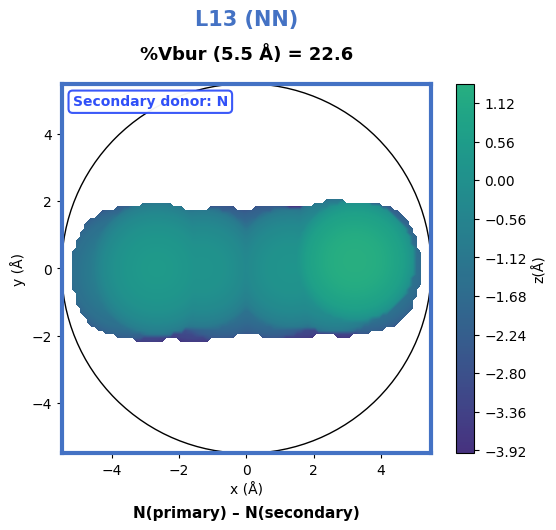

✓ L13  | NN | secondary donor = N23 | %Vbur = 22.59


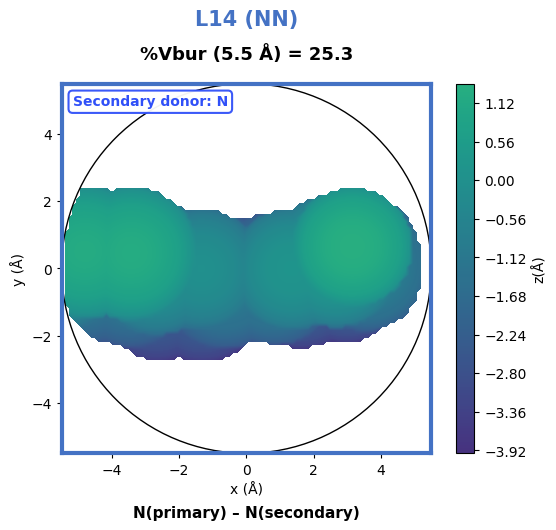

✓ L14  | NN | secondary donor = N23 | %Vbur = 25.29


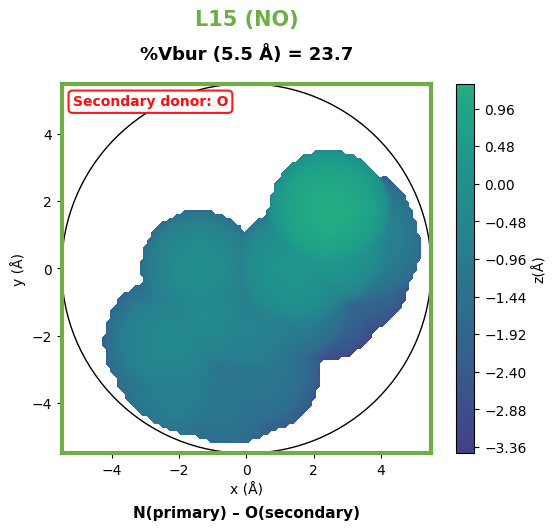

✓ L15  | NO | secondary donor = O24 | %Vbur = 23.70


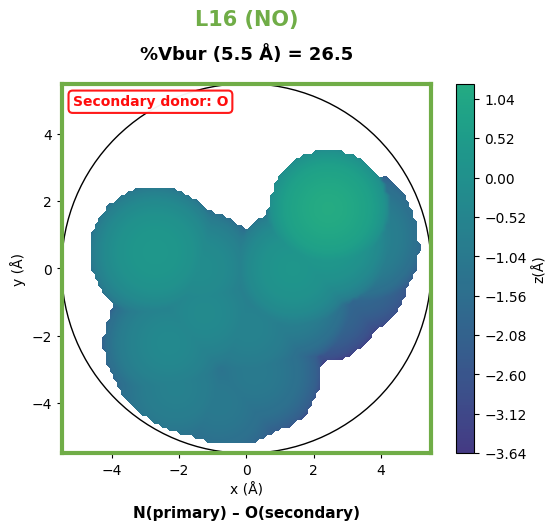

✓ L16  | NO | secondary donor = O24 | %Vbur = 26.51


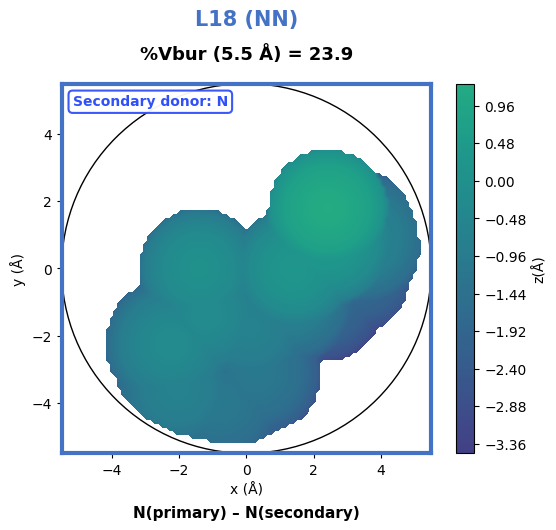

✓ L18  | NN | secondary donor = N24 | %Vbur = 23.93


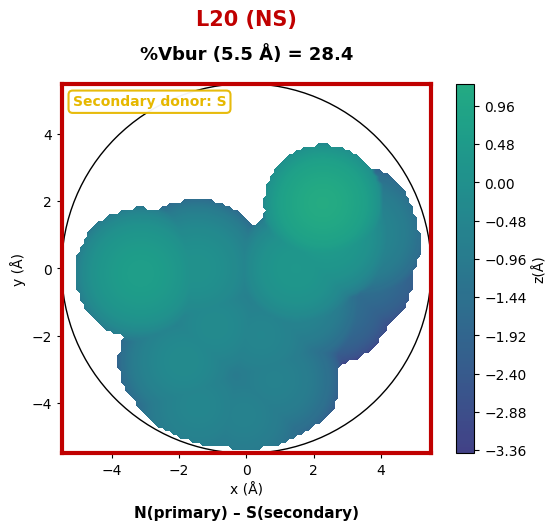

✓ L20  | NS | secondary donor = S24 | %Vbur = 28.36


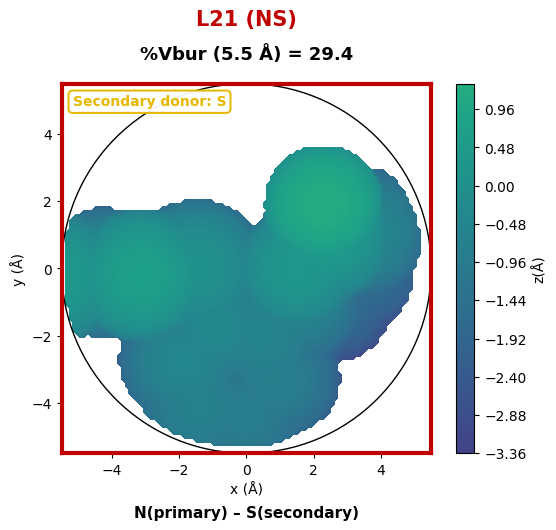

✓ L21  | NS | secondary donor = S24 | %Vbur = 29.39


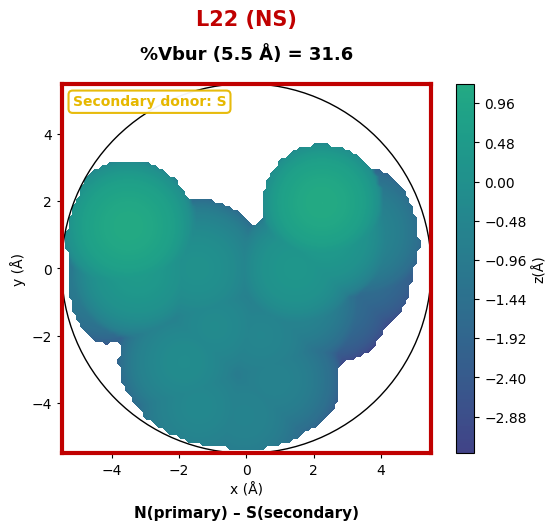

✓ L22  | NS | secondary donor = S24 | %Vbur = 31.56


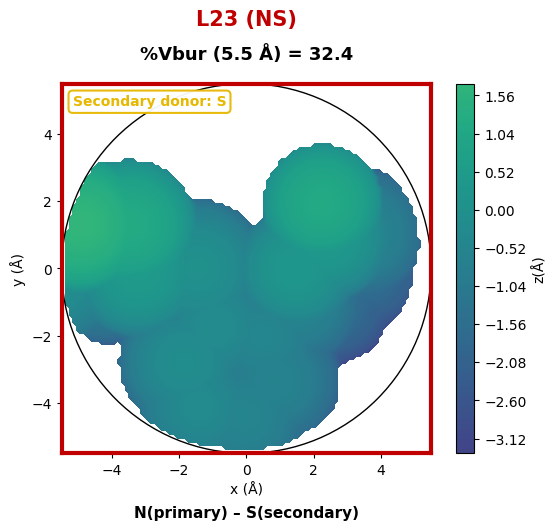

✓ L23  | NS | secondary donor = S24 | %Vbur = 32.44


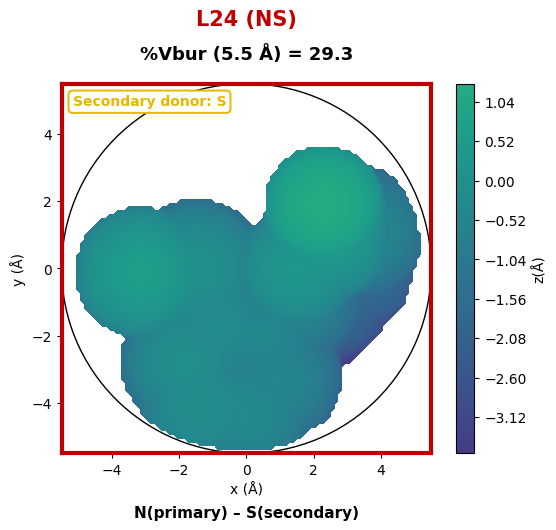

✓ L24  | NS | secondary donor = S24 | %Vbur = 29.32


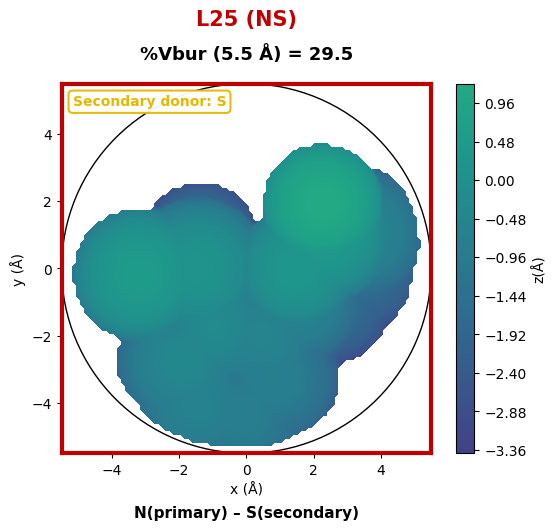

✓ L25  | NS | secondary donor = S24 | %Vbur = 29.51


In [21]:
# ============================================================
# STEP 6 — CAPTURE + CUSTOMIZE THE ACTUAL MORFEUS MAP
#
# Keeps Morfeus steric map itself.
#
# Adds:
#   NN / NO / NS
#   N / O / S secondary donor information
#   bold %Vbur
#   class-colored border
#
# NN = blue border
# NO = green border
# NS = red border
#
# NOTE:
# Steric-map colormap itself remains COMMON for all classes.
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# COLORS
# ============================================================

CLASS_COLORS = {
    "NN": "#4472C4",
    "NO": "#70AD47",
    "NS": "#C00000",
}

DONOR_COLORS = {
    "N": "#3050F8",   # blue
    "O": "#FF0D0D",   # red
    "S": "#E6B800",   # gold
}


# ============================================================
# SECONDARY DONOR IDENTIFICATION
# ============================================================

def get_secondary_donor(
    elements,
    donor1,
    donor2,
    ligand_class,
):

    donor1 = int(donor1)
    donor2 = int(donor2)

    e1 = elements[donor1 - 1]
    e2 = elements[donor2 - 1]

    # NO -> O is secondary donor
    if ligand_class == "NO":

        if e1 == "O":
            return donor1, "O"

        if e2 == "O":
            return donor2, "O"

        raise ValueError(
            "NO ligand: O donor not found."
        )


    # NS -> S is secondary donor
    if ligand_class == "NS":

        if e1 == "S":
            return donor1, "S"

        if e2 == "S":
            return donor2, "S"

        raise ValueError(
            "NS ligand: S donor not found."
        )


    # NN -> both are N
    if ligand_class == "NN":

        if e1 == "N" and e2 == "N":

            # Temporary definition:
            # donor2 = secondary N.
            #
            # Change this if your chemically defined
            # secondary N is donor1.
            return donor2, "N"

        raise ValueError(
            "NN ligand: two N donors expected."
        )


    raise ValueError(
        f"Unknown ligand class: {ligand_class}"
    )


# ============================================================
# MAIN LOOP
# ============================================================

for _, row in oriented_df.iterrows():

    ligand = row["Ligand"]
    ligand_class = row["Class"]

    donor1 = int(row["Donor1"])
    donor2 = int(row["Donor2"])

    elements, coordinates = read_xyz_file(
        row["File"]
    )

    try:

        # ====================================================
        # 1. BURIED VOLUME
        # ====================================================

        bv = calculate_buried_volume(
            elements=elements,
            coordinates=coordinates,
            donor1=donor1,
            donor2=donor2,
        )

        percent_vbur = (
            bv.fraction_buried_volume
            * 100.0
        )


        # ====================================================
        # 2. SECONDARY DONOR
        # ====================================================

        (
            secondary_atom,
            secondary_element,
        ) = get_secondary_donor(
            elements,
            donor1,
            donor2,
            ligand_class,
        )


        # ====================================================
        # 3. INTERCEPT plt.show()
        #
        # Morfeus calls show internally.
        # We temporarily stop show() from displaying/closing
        # the figure.
        # ====================================================

        original_show = plt.show

        plt.show = lambda *args, **kwargs: None


        try:

            # IMPORTANT:
            # use ONE COMMON colormap for NN/NO/NS
            bv.plot_steric_map(
                cmap="viridis"
            )

        finally:

            # Restore normal matplotlib behavior immediately.
            plt.show = original_show


        # ====================================================
        # 4. NOW CAPTURE THE MORFEUS FIGURE
        # ====================================================

        figure_numbers = plt.get_fignums()

        if len(figure_numbers) == 0:

            raise RuntimeError(
                "Could not capture Morfeus steric-map figure."
            )


        fig = plt.figure(
            figure_numbers[-1]
        )

        axes = fig.get_axes()

        if len(axes) == 0:

            raise RuntimeError(
                "Captured figure contains no axes."
            )


        # Usually:
        # axes[0] = steric map
        # axes[1] = colorbar
        #
        # Identify the large map axis.

        main_ax = max(
            axes,
            key=lambda axis:
                axis.get_position().width
                * axis.get_position().height
        )


        # ====================================================
        # 5. CLASS COLOR
        # ====================================================

        class_color = CLASS_COLORS[
            ligand_class
        ]

        donor_color = DONOR_COLORS[
            secondary_element
        ]


        # ====================================================
        # 6. CLASS-COLORED BORDER
        # ====================================================

        for spine in main_ax.spines.values():

            spine.set_visible(True)

            spine.set_color(
                class_color
            )

            spine.set_linewidth(
                3.0
            )


        # ====================================================
        # 7. TITLE
        # ====================================================

        main_ax.set_title(
            f"{ligand} ({ligand_class})",
            fontsize=15,
            fontweight="bold",
            color=class_color,
            pad=42,
        )


        # ====================================================
        # 8. BOLD %VBUR
        # ====================================================

        main_ax.text(
            0.50,
            1.055,

            f"%Vbur (5.5 Å) = "
            f"{percent_vbur:.1f}",

            transform=main_ax.transAxes,

            ha="center",
            va="bottom",

            fontsize=13,
            fontweight="bold",

            color="black",

            clip_on=False,
        )


        # ====================================================
        # 9. DONOR-TYPE LABEL
        #
        # This is chemically safer than putting an N/O/S
        # marker at an unverified projected map coordinate.
        # ====================================================

        if ligand_class == "NN":

            donor_description = (
                "N(primary) – N(secondary)"
            )

        elif ligand_class == "NO":

            donor_description = (
                "N(primary) – O(secondary)"
            )

        else:

            donor_description = (
                "N(primary) – S(secondary)"
            )


        main_ax.text(
            0.50,
            -0.14,

            donor_description,

            transform=main_ax.transAxes,

            ha="center",
            va="top",

            fontsize=11,
            fontweight="bold",

            color="black",

            clip_on=False,
        )


        # ====================================================
        # 10. COLOR THE SECONDARY-DONOR LETTER
        #
        # Small donor identity box.
        # ====================================================

        main_ax.text(
            0.03,
            0.97,

            f"Secondary donor: {secondary_element}",

            transform=main_ax.transAxes,

            ha="left",
            va="top",

            fontsize=10,
            fontweight="bold",

            color=donor_color,

            bbox={
                "boxstyle": "round,pad=0.30",
                "facecolor": "white",
                "edgecolor": donor_color,
                "linewidth": 1.5,
                "alpha": 0.95,
            },

            zorder=50,
        )


        # ====================================================
        # 11. SAVE
        # ====================================================

        output_png = os.path.join(
            VBUR_FOLDER,

            f"{ligand}_"
            f"{ligand_class}_"
            f"Vbur_5.5A_"
            f"FinalStericMap.png",
        )


        fig.savefig(
            output_png,

            dpi=600,

            bbox_inches="tight",

            facecolor="white",
        )


        # ====================================================
        # 12. DISPLAY ONCE
        # ====================================================

        original_show()


        # ====================================================
        # 13. CLOSE
        # ====================================================

        plt.close(fig)


        # ====================================================
        # 14. SUMMARY
        # ====================================================

        print(
            f"✓ {ligand:4s} | "
            f"{ligand_class:2s} | "
            f"secondary donor = "
            f"{secondary_element}"
            f"{secondary_atom} | "
            f"%Vbur = "
            f"{percent_vbur:.2f}"
        )


    except Exception as error:

        # Always restore show if something fails.
        plt.show = original_show \
            if "original_show" in locals() \
            else plt.show

        plt.close("all")

        print(
            f"MAP ERROR: "
            f"{ligand}: "
            f"{error}"
        )

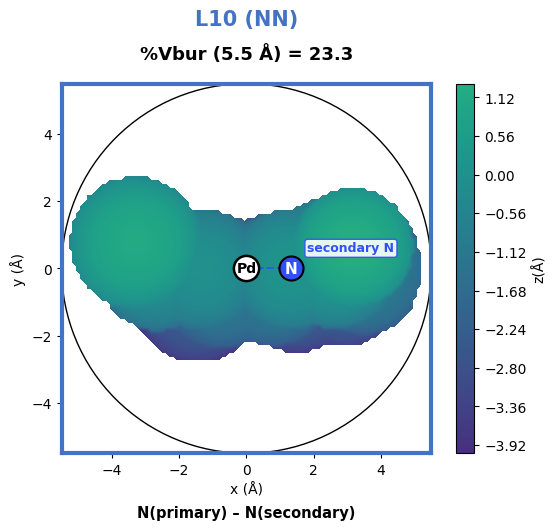

✓ L10  | NN | secondary donor = N23 | map position = (1.32, 0.00) Å | %Vbur = 23.26


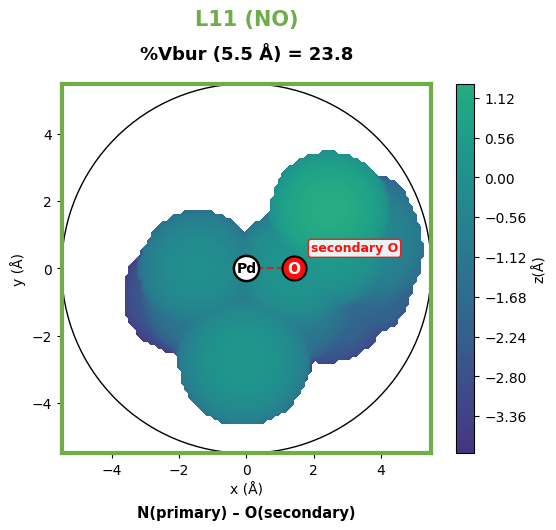

✓ L11  | NO | secondary donor = O24 | map position = (1.42, 0.00) Å | %Vbur = 23.82


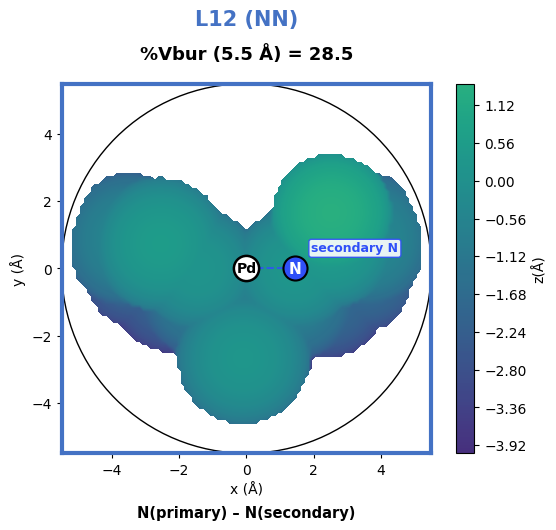

✓ L12  | NN | secondary donor = N24 | map position = (1.44, 0.00) Å | %Vbur = 28.48


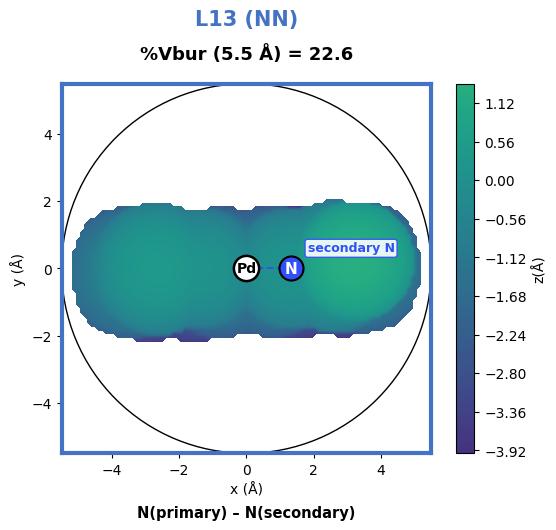

✓ L13  | NN | secondary donor = N23 | map position = (1.32, 0.00) Å | %Vbur = 22.59


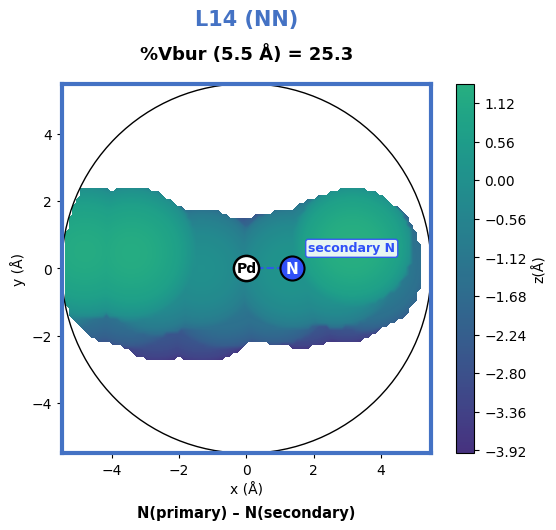

✓ L14  | NN | secondary donor = N23 | map position = (1.34, 0.00) Å | %Vbur = 25.29


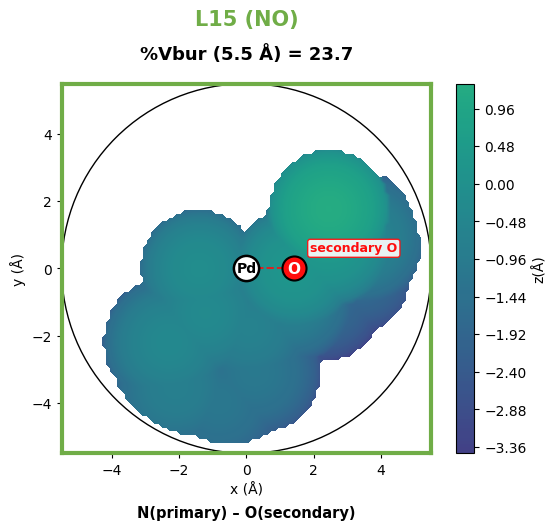

✓ L15  | NO | secondary donor = O24 | map position = (1.40, 0.00) Å | %Vbur = 23.70


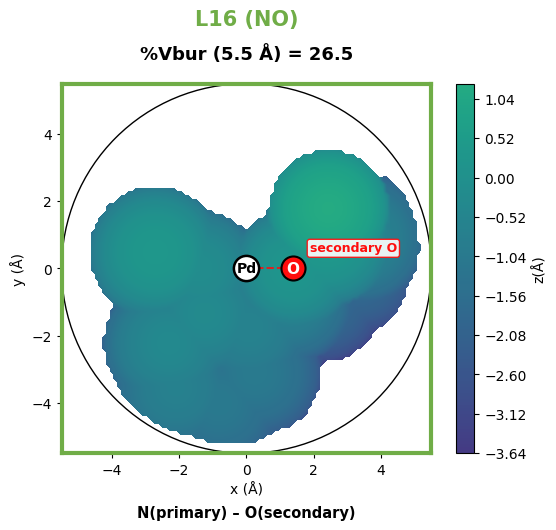

✓ L16  | NO | secondary donor = O24 | map position = (1.39, 0.00) Å | %Vbur = 26.51


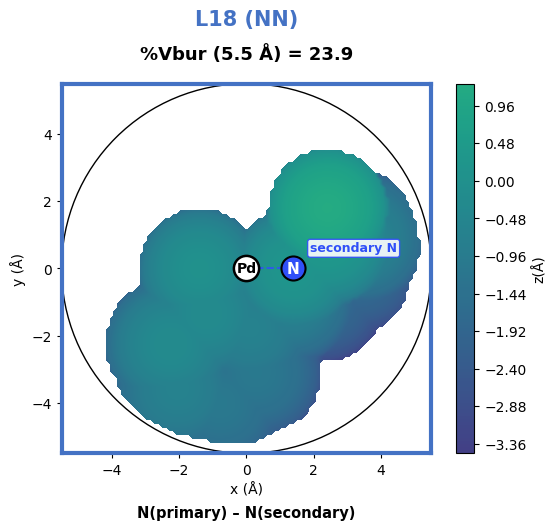

✓ L18  | NN | secondary donor = N24 | map position = (1.40, 0.00) Å | %Vbur = 23.93


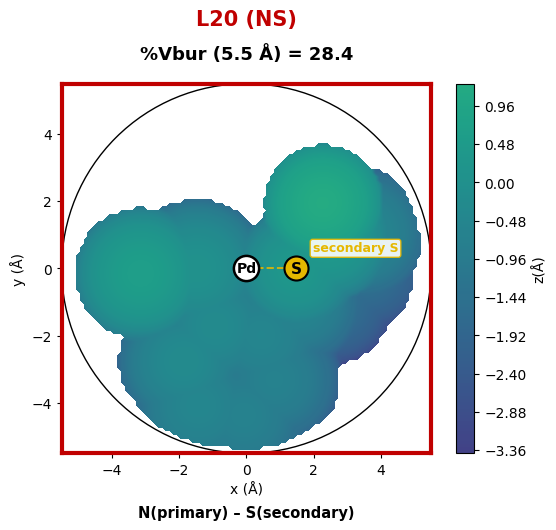

✓ L20  | NS | secondary donor = S24 | map position = (1.48, 0.00) Å | %Vbur = 28.36


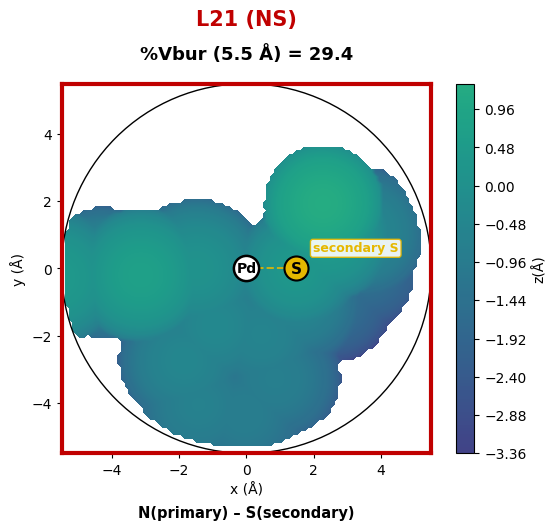

✓ L21  | NS | secondary donor = S24 | map position = (1.48, 0.00) Å | %Vbur = 29.39


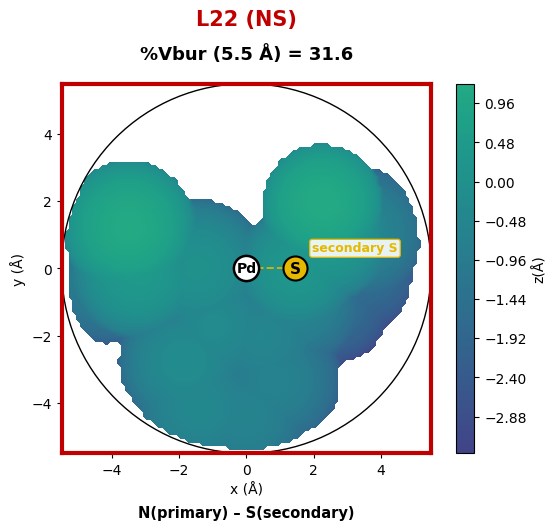

✓ L22  | NS | secondary donor = S24 | map position = (1.46, 0.00) Å | %Vbur = 31.56


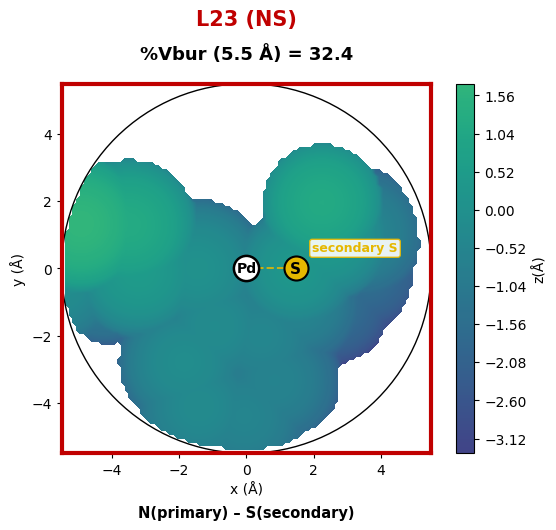

✓ L23  | NS | secondary donor = S24 | map position = (1.46, 0.00) Å | %Vbur = 32.44


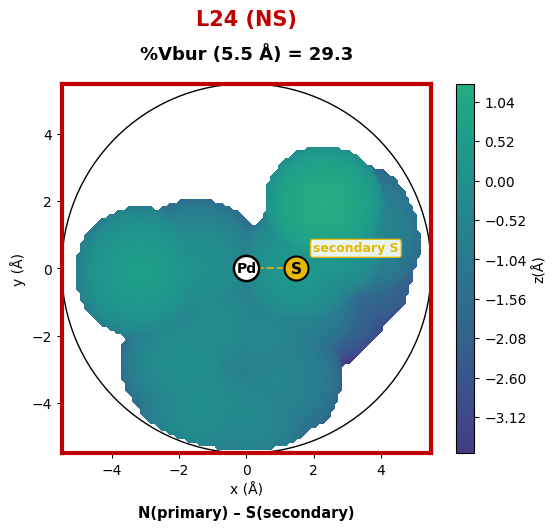

✓ L24  | NS | secondary donor = S24 | map position = (1.49, 0.00) Å | %Vbur = 29.32


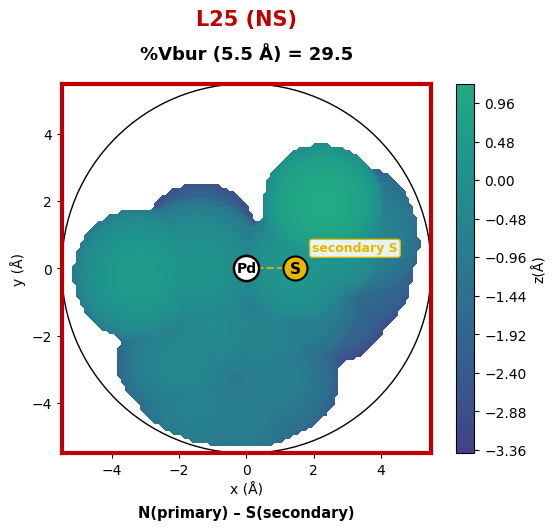

✓ L25  | NS | secondary donor = S24 | map position = (1.46, 0.00) Å | %Vbur = 29.51


In [22]:
# ============================================================
# STEP 6 — FINAL DONOR-LOCATED %VBUR MAP
#
# Shows:
#   • actual Morfeus steric map
#   • Pd center
#   • projected secondary donor position
#       NN -> N  blue
#       NO -> O  red
#       NS -> S  gold
#   • bold %Vbur
#   • NN / NO / NS class-colored frame
#
# IMPORTANT:
# The donor marker indicates donor LOCATION.
# It is NOT an atom-by-atom decomposition of %Vbur.
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. COLORS
# ============================================================

CLASS_COLORS = {
    "NN": "#4472C4",   # blue
    "NO": "#70AD47",   # green
    "NS": "#C00000",   # red
}

DONOR_COLORS = {
    "N": "#3050F8",    # nitrogen blue
    "O": "#FF0D0D",    # oxygen red
    "S": "#E6B800",    # sulfur gold
}


# ============================================================
# 2. SECONDARY DONOR IDENTIFICATION
# ============================================================

def get_secondary_donor(
    elements,
    donor1,
    donor2,
    ligand_class,
):

    donor1 = int(donor1)
    donor2 = int(donor2)

    e1 = str(elements[donor1 - 1])
    e2 = str(elements[donor2 - 1])

    # NO -> O
    if ligand_class == "NO":

        if e1 == "O":
            return donor1, "O"

        if e2 == "O":
            return donor2, "O"

        raise ValueError(
            "NO ligand: O donor not found."
        )

    # NS -> S
    if ligand_class == "NS":

        if e1 == "S":
            return donor1, "S"

        if e2 == "S":
            return donor2, "S"

        raise ValueError(
            "NS ligand: S donor not found."
        )

    # NN -> both N
    if ligand_class == "NN":

        if e1 == "N" and e2 == "N":

            # IMPORTANT:
            # Currently donor2 is treated as secondary N.
            # Change here if your chemically defined
            # secondary N is donor1.
            return donor2, "N"

        raise ValueError(
            "NN ligand: expected N/N donors."
        )

    raise ValueError(
        f"Unknown ligand class: {ligand_class}"
    )


# ============================================================
# 3. MORFEUS-LIKE DONOR-DEFINED COORDINATE SYSTEM
# ============================================================

def normalize_vector(v):

    v = np.asarray(
        v,
        dtype=float,
    )

    norm = np.linalg.norm(v)

    if norm < 1.0e-12:
        raise ValueError(
            "Cannot normalize zero vector."
        )

    return v / norm


def transform_to_donor_map_coordinates(
    coordinates,
    pd_atom,
    donor1,
    donor2,
):
    """
    Build a Pd-centered donor-defined coordinate system.

    Pd = origin.

    z axis:
        Pd -> midpoint of donor1/donor2

    x direction:
        donor1/donor2 separation projected perpendicular
        to z.

    y completes the right-handed coordinate system.

    Returns transformed coordinates.
    """

    xyz = np.asarray(
        coordinates,
        dtype=float,
    ).copy()

    # --------------------------------------------------------
    # Translate Pd to origin
    # --------------------------------------------------------

    pd_xyz = xyz[
        pd_atom - 1
    ].copy()

    xyz = xyz - pd_xyz


    d1 = xyz[
        donor1 - 1
    ]

    d2 = xyz[
        donor2 - 1
    ]


    # --------------------------------------------------------
    # Z axis = Pd -> donor midpoint
    # --------------------------------------------------------

    donor_midpoint = (
        d1 + d2
    ) / 2.0

    z_axis = normalize_vector(
        donor_midpoint
    )


    # --------------------------------------------------------
    # X axis = donor separation projected perpendicular to Z
    # --------------------------------------------------------

    donor_difference = (
        d2 - d1
    )

    x_temp = (
        donor_difference
        - np.dot(
            donor_difference,
            z_axis,
        ) * z_axis
    )

    x_axis = normalize_vector(
        x_temp
    )


    # --------------------------------------------------------
    # Y axis
    # --------------------------------------------------------

    y_axis = normalize_vector(
        np.cross(
            z_axis,
            x_axis,
        )
    )


    # Rebuild X for numerical orthogonality
    x_axis = normalize_vector(
        np.cross(
            y_axis,
            z_axis,
        )
    )


    # --------------------------------------------------------
    # Rotation
    # --------------------------------------------------------

    rotation = np.vstack([
        x_axis,
        y_axis,
        z_axis,
    ])

    transformed = (
        rotation @ xyz.T
    ).T

    return transformed


# ============================================================
# 4. MAIN LOOP
# ============================================================

for _, row in oriented_df.iterrows():

    ligand = str(
        row["Ligand"]
    )

    ligand_class = str(
        row["Class"]
    )

    donor1 = int(
        row["Donor1"]
    )

    donor2 = int(
        row["Donor2"]
    )

    elements, coordinates = read_xyz_file(
        row["File"]
    )

    try:

        # ====================================================
        # A. BURIED VOLUME
        # ====================================================

        bv = calculate_buried_volume(
            elements=elements,
            coordinates=coordinates,
            donor1=donor1,
            donor2=donor2,
        )

        percent_vbur = (
            bv.fraction_buried_volume
            * 100.0
        )


        # ====================================================
        # B. SECONDARY DONOR
        # ====================================================

        (
            secondary_atom,
            secondary_element,
        ) = get_secondary_donor(
            elements=elements,
            donor1=donor1,
            donor2=donor2,
            ligand_class=ligand_class,
        )


        # ====================================================
        # C. TRANSFORM COORDINATES
        # ====================================================

        map_coordinates = (
            transform_to_donor_map_coordinates(
                coordinates=coordinates,
                pd_atom=PD_ATOM,
                donor1=donor1,
                donor2=donor2,
            )
        )


        secondary_xyz = (
            map_coordinates[
                secondary_atom - 1
            ]
        )


        # ====================================================
        # D. IMPORTANT PROJECTION
        #
        # Steric map is viewed down the donor-defined Z axis.
        #
        # Therefore plotted coordinates are X/Y.
        # ====================================================

        donor_map_x = float(
            secondary_xyz[0]
        )

        donor_map_y = float(
            secondary_xyz[1]
        )


        # ====================================================
        # E. CAPTURE MORFEUS FIGURE
        # ====================================================

        original_show = plt.show

        plt.show = (
            lambda *args, **kwargs: None
        )


        try:

            # SAME colormap for all classes.
            # Important for direct steric comparison.

            bv.plot_steric_map(
                cmap="viridis"
            )

        finally:

            plt.show = original_show


        # ====================================================
        # F. GET FIGURE
        # ====================================================

        figure_numbers = (
            plt.get_fignums()
        )

        if not figure_numbers:

            raise RuntimeError(
                "Could not capture Morfeus figure."
            )


        fig = plt.figure(
            figure_numbers[-1]
        )

        axes = fig.get_axes()

        if not axes:

            raise RuntimeError(
                "Captured Morfeus figure "
                "contains no axes."
            )


        # Main map axis = largest axis.
        # Avoid selecting colorbar.

        main_ax = max(
            axes,
            key=lambda a:
                a.get_position().width
                * a.get_position().height
        )


        # ====================================================
        # G. COLORS
        # ====================================================

        class_color = (
            CLASS_COLORS[
                ligand_class
            ]
        )

        donor_color = (
            DONOR_COLORS[
                secondary_element
            ]
        )


        # ====================================================
        # H. CLASS BORDER
        # ====================================================

        for spine in (
            main_ax.spines.values()
        ):

            spine.set_visible(True)

            spine.set_color(
                class_color
            )

            spine.set_linewidth(
                3.0
            )


        # ====================================================
        # I. Pd CENTER
        #
        # Pd is the origin of the steric analysis.
        # ====================================================

        main_ax.scatter(
            0.0,
            0.0,

            s=330,

            facecolor="white",
            edgecolor="black",

            linewidth=1.8,

            zorder=50,
        )


        main_ax.text(
            0.0,
            0.0,

            "Pd",

            ha="center",
            va="center",

            fontsize=10,
            fontweight="bold",

            color="black",

            zorder=51,
        )


        # ====================================================
        # J. SECONDARY DONOR MARKER
        # ====================================================

        main_ax.scatter(
            donor_map_x,
            donor_map_y,

            s=300,

            facecolor=donor_color,
            edgecolor="black",

            linewidth=1.5,

            zorder=55,
        )


        donor_text_color = (
            "black"
            if secondary_element == "S"
            else "white"
        )


        main_ax.text(
            donor_map_x,
            donor_map_y,

            secondary_element,

            ha="center",
            va="center",

            fontsize=11,
            fontweight="bold",

            color=donor_text_color,

            zorder=56,
        )


        # ====================================================
        # K. Pd -> SECONDARY DONOR GUIDE
        # ====================================================

        main_ax.plot(
            [
                0.0,
                donor_map_x
            ],
            [
                0.0,
                donor_map_y
            ],

            color=donor_color,

            linewidth=1.4,
            linestyle="--",

            alpha=0.85,

            zorder=45,
        )


        # ====================================================
        # L. SECONDARY DONOR LABEL
        # ====================================================

        main_ax.annotate(
            f"secondary {secondary_element}",

            xy=(
                donor_map_x,
                donor_map_y,
            ),

            xytext=(
                12,
                12,
            ),

            textcoords="offset points",

            fontsize=9,
            fontweight="bold",

            color=donor_color,

            bbox={
                "boxstyle":
                    "round,pad=0.20",

                "facecolor":
                    "white",

                "edgecolor":
                    donor_color,

                "linewidth":
                    1.0,

                "alpha":
                    0.90,
            },

            zorder=60,
        )


        # ====================================================
        # M. TITLE
        # ====================================================

        main_ax.set_title(
            f"{ligand} ({ligand_class})",

            fontsize=15,
            fontweight="bold",

            color=class_color,

            pad=42,
        )


        # ====================================================
        # N. BOLD %VBUR
        # ====================================================

        main_ax.text(
            0.50,
            1.055,

            f"%Vbur (5.5 Å) = "
            f"{percent_vbur:.1f}",

            transform=main_ax.transAxes,

            ha="center",
            va="bottom",

            fontsize=13,
            fontweight="bold",

            color="black",

            clip_on=False,
        )


        # ====================================================
        # O. DONOR PAIR DESCRIPTION
        # ====================================================

        if ligand_class == "NN":

            donor_description = (
                "N(primary) – N(secondary)"
            )

        elif ligand_class == "NO":

            donor_description = (
                "N(primary) – O(secondary)"
            )

        else:

            donor_description = (
                "N(primary) – S(secondary)"
            )


        main_ax.text(
            0.50,
            -0.14,

            donor_description,

            transform=main_ax.transAxes,

            ha="center",
            va="top",

            fontsize=10.5,
            fontweight="bold",

            color="black",

            clip_on=False,
        )


        # ====================================================
        # P. SAVE
        # ====================================================

        output_png = os.path.join(
            VBUR_FOLDER,

            f"{ligand}_"
            f"{ligand_class}_"
            f"Vbur_5.5A_"
            f"DonorLocation.png",
        )


        fig.savefig(
            output_png,

            dpi=600,

            bbox_inches="tight",

            facecolor="white",
        )


        # ====================================================
        # Q. DISPLAY EXACTLY ONCE
        # ====================================================

        original_show()


        # ====================================================
        # R. CLOSE
        # ====================================================

        plt.close(fig)


        # ====================================================
        # S. PRINT CHECK
        # ====================================================

        print(
            f"✓ {ligand:4s} | "
            f"{ligand_class:2s} | "
            f"secondary donor = "
            f"{secondary_element}"
            f"{secondary_atom} | "
            f"map position = "
            f"({donor_map_x:.2f}, "
            f"{donor_map_y:.2f}) Å | "
            f"%Vbur = "
            f"{percent_vbur:.2f}"
        )


    except Exception as error:

        # Restore show if necessary
        if "original_show" in locals():
            plt.show = original_show

        plt.close("all")

        print(
            f"MAP ERROR: "
            f"{ligand}: "
            f"{error}"
        )

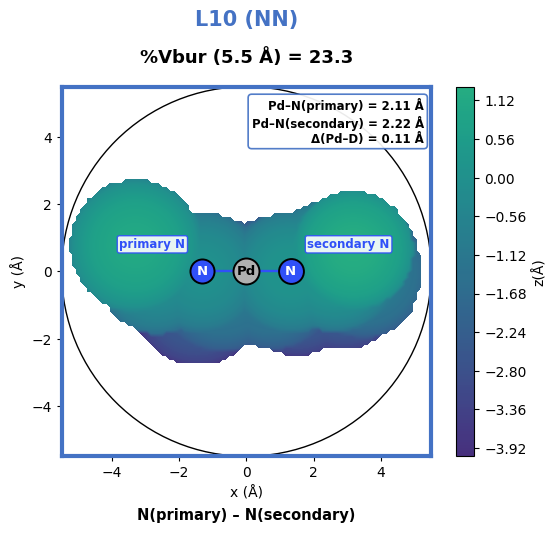

✓ L10  | NN | primary N = 20 | secondary = N23 | Pd–N = 2.107 Å | Pd–N = 2.218 Å | ΔPd-D = 0.112 Å | %Vbur = 23.26


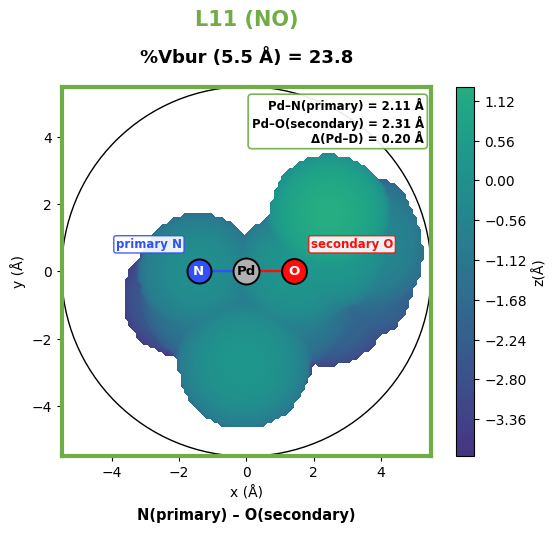

✓ L11  | NO | primary N = 20 | secondary = O24 | Pd–N = 2.115 Å | Pd–O = 2.311 Å | ΔPd-D = 0.196 Å | %Vbur = 23.82


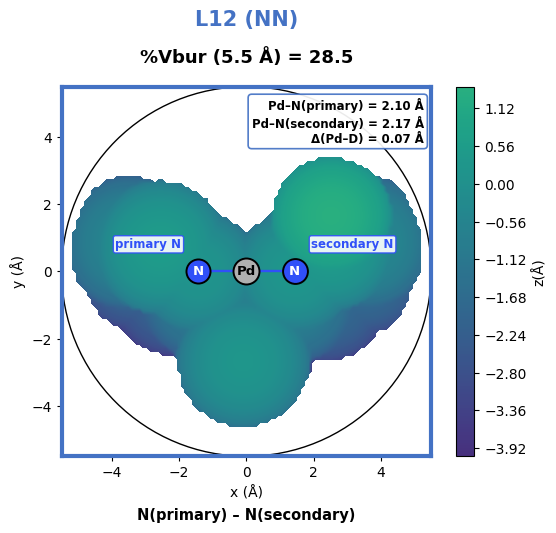

✓ L12  | NN | primary N = 20 | secondary = N24 | Pd–N = 2.101 Å | Pd–N = 2.168 Å | ΔPd-D = 0.068 Å | %Vbur = 28.48


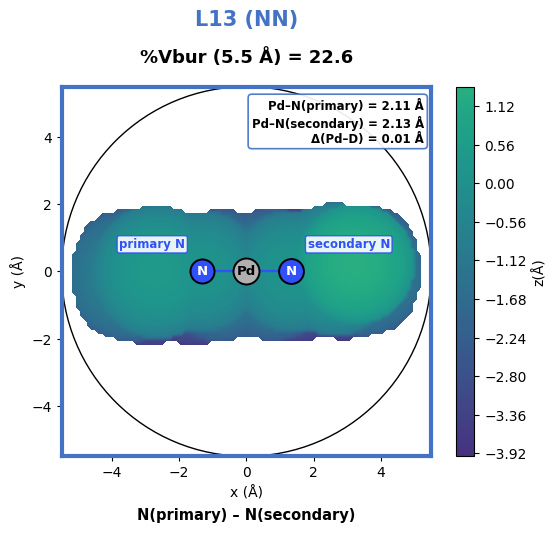

✓ L13  | NN | primary N = 20 | secondary = N23 | Pd–N = 2.113 Å | Pd–N = 2.127 Å | ΔPd-D = 0.014 Å | %Vbur = 22.59


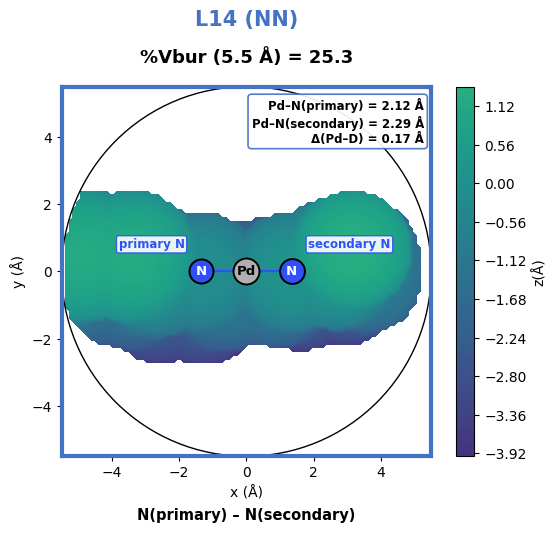

✓ L14  | NN | primary N = 20 | secondary = N23 | Pd–N = 2.121 Å | Pd–N = 2.286 Å | ΔPd-D = 0.166 Å | %Vbur = 25.29


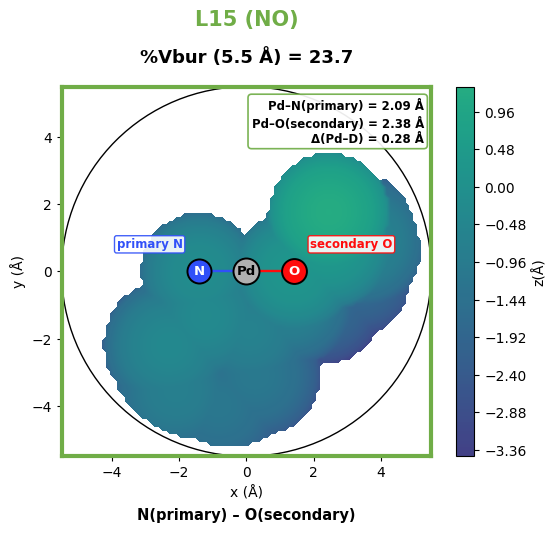

✓ L15  | NO | primary N = 20 | secondary = O24 | Pd–N = 2.093 Å | Pd–O = 2.377 Å | ΔPd-D = 0.284 Å | %Vbur = 23.70


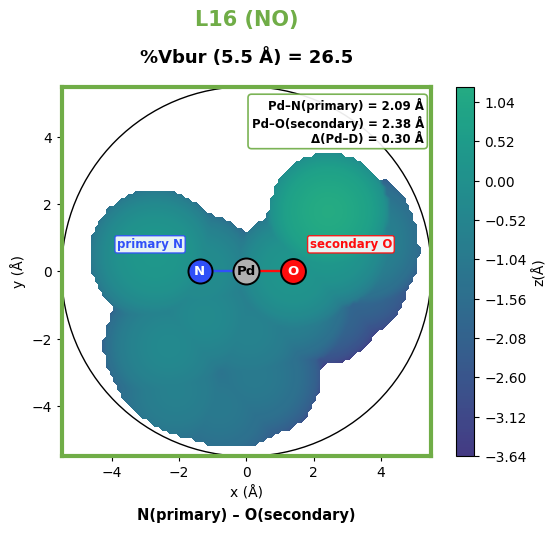

✓ L16  | NO | primary N = 20 | secondary = O24 | Pd–N = 2.089 Å | Pd–O = 2.385 Å | ΔPd-D = 0.296 Å | %Vbur = 26.51


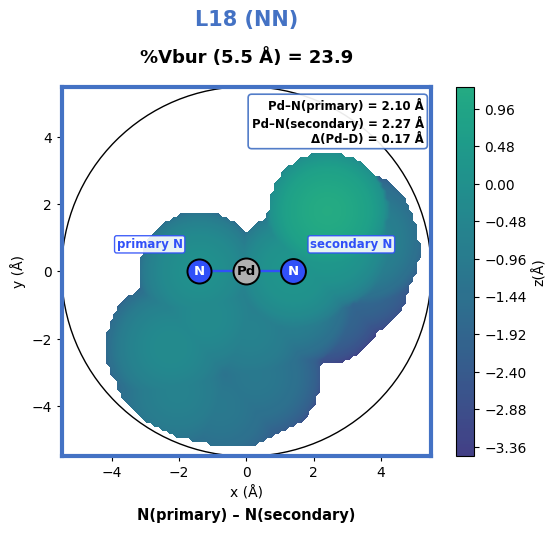

✓ L18  | NN | primary N = 20 | secondary = N24 | Pd–N = 2.104 Å | Pd–N = 2.275 Å | ΔPd-D = 0.171 Å | %Vbur = 23.93


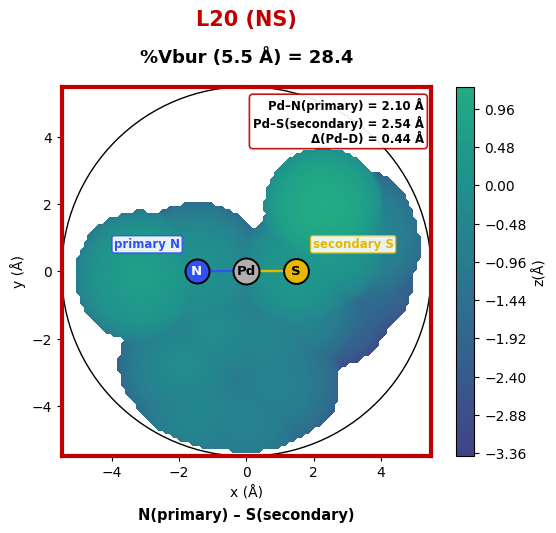

✓ L20  | NS | primary N = 20 | secondary = S24 | Pd–N = 2.096 Å | Pd–S = 2.540 Å | ΔPd-D = 0.444 Å | %Vbur = 28.36


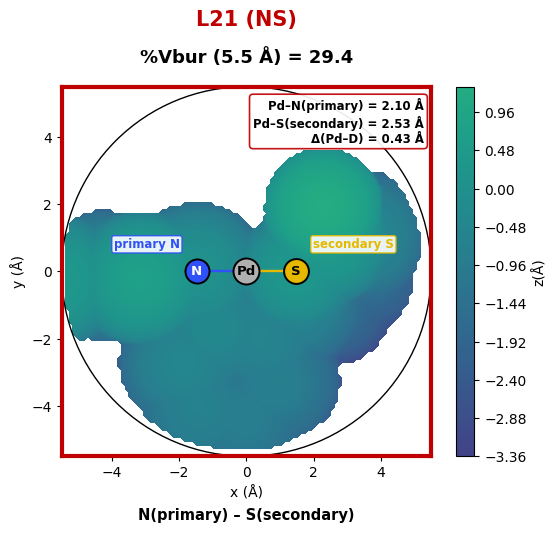

✓ L21  | NS | primary N = 20 | secondary = S24 | Pd–N = 2.098 Å | Pd–S = 2.526 Å | ΔPd-D = 0.428 Å | %Vbur = 29.39


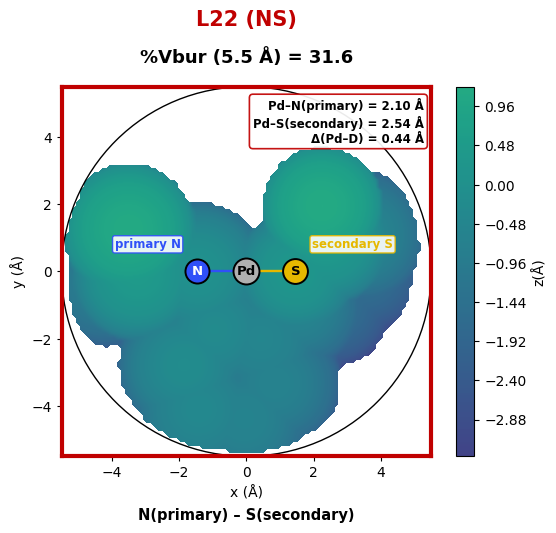

✓ L22  | NS | primary N = 20 | secondary = S24 | Pd–N = 2.102 Å | Pd–S = 2.539 Å | ΔPd-D = 0.437 Å | %Vbur = 31.56


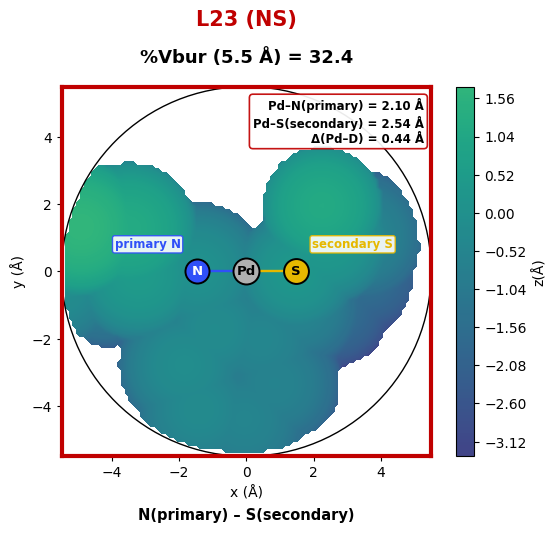

✓ L23  | NS | primary N = 20 | secondary = S24 | Pd–N = 2.100 Å | Pd–S = 2.544 Å | ΔPd-D = 0.444 Å | %Vbur = 32.44


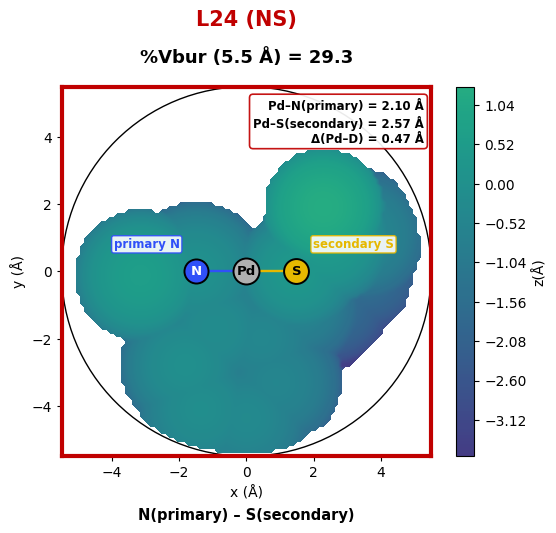

✓ L24  | NS | primary N = 20 | secondary = S24 | Pd–N = 2.103 Å | Pd–S = 2.569 Å | ΔPd-D = 0.466 Å | %Vbur = 29.32


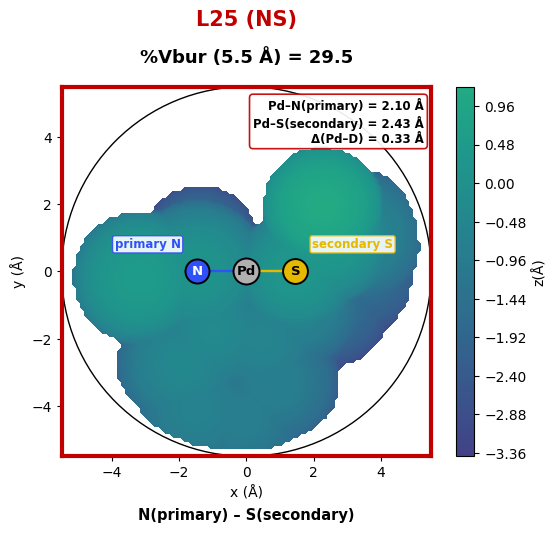

✓ L25  | NS | primary N = 20 | secondary = S24 | Pd–N = 2.100 Å | Pd–S = 2.432 Å | ΔPd-D = 0.332 Å | %Vbur = 29.51


In [23]:
# ============================================================
# STEP 6 — COMPLETE FINAL BURIED-VOLUME VISUALIZATION
# ============================================================
#
# Shows on every map:
#
#   1. Ligand name + class: L10 (NN), L11 (NO), L20 (NS)...
#   2. %Vbur (5.5 Å) in bold
#   3. Pd center
#   4. Primary N donor
#   5. Secondary donor:
#          NN -> N
#          NO -> O
#          NS -> S
#   6. Pd–secondary donor distance
#   7. NN / NO / NS class-colored frame
#   8. SAME steric-map color scale for all ligand classes
#
# Optional:
#   9. Substrate C(beta) can be activated later
#
# IMPORTANT:
# The N/O/S marker shows the donor LOCATION.
# It does NOT mean that N/O/S alone contributes that %Vbur.
# ============================================================


import os
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# USER SETTING
# ============================================================

# ------------------------------------------------------------
# SUBSTRATE C(beta)
#
# Leave as None for now.
#
# When you know the atom number, for example atom 8:
#
# CBETA_ATOM = 8
#
# ------------------------------------------------------------

CBETA_ATOM = None


# ============================================================
# COLORS
# ============================================================

# Outer frame / ligand-class identification
CLASS_COLORS = {

    "NN": "#4472C4",     # blue

    "NO": "#70AD47",     # green

    "NS": "#C00000",     # red
}


# Conventional atom colors
ATOM_COLORS = {

    "Pd": "#B0B0B0",

    "N": "#3050F8",

    "O": "#FF0D0D",

    "S": "#E6B800",

    "C": "#404040",
}


# ============================================================
# VECTOR NORMALIZATION
# ============================================================

def normalize_vector(v):

    v = np.asarray(
        v,
        dtype=float
    )

    norm = np.linalg.norm(v)

    if norm < 1.0e-12:

        raise ValueError(
            "Cannot normalize zero-length vector."
        )

    return v / norm


# ============================================================
# IDENTIFY SECONDARY DONOR
# ============================================================

def get_secondary_donor(
    elements,
    donor1,
    donor2,
    ligand_class
):

    donor1 = int(donor1)
    donor2 = int(donor2)

    e1 = str(
        elements[donor1 - 1]
    )

    e2 = str(
        elements[donor2 - 1]
    )


    # --------------------------------------------------------
    # NO
    # O = secondary donor
    # --------------------------------------------------------

    if ligand_class == "NO":

        if e1 == "O":
            return donor1, "O"

        if e2 == "O":
            return donor2, "O"

        raise ValueError(
            "NO ligand: O donor not found."
        )


    # --------------------------------------------------------
    # NS
    # S = secondary donor
    # --------------------------------------------------------

    elif ligand_class == "NS":

        if e1 == "S":
            return donor1, "S"

        if e2 == "S":
            return donor2, "S"

        raise ValueError(
            "NS ligand: S donor not found."
        )


    # --------------------------------------------------------
    # NN
    # both donors = N
    # --------------------------------------------------------

    elif ligand_class == "NN":

        if (
            e1 == "N"
            and
            e2 == "N"
        ):

            # Current convention:
            # donor2 = secondary N
            #
            # If your chemical atom assignment says donor1
            # is secondary, change donor2 -> donor1 here.

            return donor2, "N"

        raise ValueError(
            "NN ligand: expected two N donors."
        )


    else:

        raise ValueError(
            f"Unknown ligand class: {ligand_class}"
        )


# ============================================================
# IDENTIFY PRIMARY DONOR
# ============================================================

def get_primary_donor(
    donor1,
    donor2,
    secondary_atom
):

    donor1 = int(donor1)
    donor2 = int(donor2)

    if secondary_atom == donor1:

        return donor2

    else:

        return donor1


# ============================================================
# CREATE DONOR-DEFINED MAP COORDINATE SYSTEM
# ============================================================

def transform_to_map_coordinates(
    coordinates,
    pd_atom,
    donor1,
    donor2
):

    xyz = np.asarray(
        coordinates,
        dtype=float
    ).copy()


    # --------------------------------------------------------
    # Pd -> origin
    # --------------------------------------------------------

    pd_xyz = xyz[
        pd_atom - 1
    ].copy()

    xyz = (
        xyz
        - pd_xyz
    )


    # --------------------------------------------------------
    # Donor coordinates
    # --------------------------------------------------------

    d1 = xyz[
        donor1 - 1
    ]

    d2 = xyz[
        donor2 - 1
    ]


    # --------------------------------------------------------
    # Z axis
    #
    # Pd -> midpoint of two donors
    # --------------------------------------------------------

    donor_midpoint = (
        d1 + d2
    ) / 2.0

    z_axis = normalize_vector(
        donor_midpoint
    )


    # --------------------------------------------------------
    # X axis
    #
    # donor1 -> donor2 direction
    # perpendicular to Z
    # --------------------------------------------------------

    donor_difference = (
        d2 - d1
    )

    x_temp = (
        donor_difference
        -
        np.dot(
            donor_difference,
            z_axis
        )
        * z_axis
    )

    x_axis = normalize_vector(
        x_temp
    )


    # --------------------------------------------------------
    # Y axis
    # --------------------------------------------------------

    y_axis = normalize_vector(

        np.cross(
            z_axis,
            x_axis
        )
    )


    # Recalculate X for orthogonality
    x_axis = normalize_vector(

        np.cross(
            y_axis,
            z_axis
        )
    )


    # --------------------------------------------------------
    # Rotation matrix
    # --------------------------------------------------------

    rotation = np.vstack(
        [
            x_axis,
            y_axis,
            z_axis
        ]
    )


    transformed = (

        rotation
        @ xyz.T

    ).T


    return transformed


# ============================================================
# GET 2D MAP POSITION
# ============================================================

def get_map_xy(
    transformed_coordinates,
    atom_number
):

    xyz = transformed_coordinates[
        int(atom_number) - 1
    ]

    return (
        float(xyz[0]),
        float(xyz[1])
    )


# ============================================================
# DRAW ATOM ON STERIC MAP
# ============================================================

def draw_map_atom(
    ax,
    x,
    y,
    label,
    color,
    size=280
):

    ax.scatter(

        x,
        y,

        s=size,

        facecolor=color,

        edgecolor="black",

        linewidth=1.4,

        zorder=60
    )


    # --------------------------------------------------------
    # Text color
    # --------------------------------------------------------

    if label in [
        "S",
        "Pd",
        "Cβ"
    ]:

        text_color = "black"

    else:

        text_color = "white"


    ax.text(

        x,
        y,

        label,

        ha="center",
        va="center",

        fontsize=9.5,

        fontweight="bold",

        color=text_color,

        zorder=61
    )


# ============================================================
# MAIN LOOP
# ============================================================

for _, row in oriented_df.iterrows():


    # --------------------------------------------------------
    # Basic information
    # --------------------------------------------------------

    ligand = str(
        row["Ligand"]
    )

    ligand_class = str(
        row["Class"]
    )

    donor1 = int(
        row["Donor1"]
    )

    donor2 = int(
        row["Donor2"]
    )


    elements, coordinates = read_xyz_file(
        row["File"]
    )


    try:

        # ====================================================
        # 1. CALCULATE BURIED VOLUME
        # ====================================================

        bv = calculate_buried_volume(

            elements=elements,

            coordinates=coordinates,

            donor1=donor1,

            donor2=donor2
        )


        percent_vbur = (

            bv.fraction_buried_volume

            * 100.0
        )


        # ====================================================
        # 2. IDENTIFY SECONDARY DONOR
        # ====================================================

        (
            secondary_atom,
            secondary_element

        ) = get_secondary_donor(

            elements=elements,

            donor1=donor1,

            donor2=donor2,

            ligand_class=ligand_class
        )


        # ====================================================
        # 3. IDENTIFY PRIMARY DONOR
        # ====================================================

        primary_atom = get_primary_donor(

            donor1=donor1,

            donor2=donor2,

            secondary_atom=secondary_atom
        )


        primary_element = str(

            elements[
                primary_atom - 1
            ]
        )


        # ====================================================
        # SAFETY CHECK
        # Primary donor should be N
        # ====================================================

        if primary_element != "N":

            print(
                f"WARNING {ligand}: "
                f"primary donor detected as "
                f"{primary_element}"
            )


        # ====================================================
        # 4. TRUE 3D Pd–DONOR DISTANCES
        # ====================================================

        pd_xyz_original = coordinates[
            PD_ATOM - 1
        ]


        primary_xyz_original = coordinates[
            primary_atom - 1
        ]


        secondary_xyz_original = coordinates[
            secondary_atom - 1
        ]


        pd_primary_distance = float(

            np.linalg.norm(

                primary_xyz_original
                -
                pd_xyz_original
            )
        )


        pd_secondary_distance = float(

            np.linalg.norm(

                secondary_xyz_original
                -
                pd_xyz_original
            )
        )


        # ====================================================
        # 5. Pd–DONOR ASYMMETRY
        # ====================================================

        delta_pd_donor = abs(

            pd_secondary_distance
            -
            pd_primary_distance
        )


        # ====================================================
        # 6. TRANSFORM TO COMMON MAP COORDINATES
        # ====================================================

        map_coordinates = transform_to_map_coordinates(

            coordinates=coordinates,

            pd_atom=PD_ATOM,

            donor1=donor1,

            donor2=donor2
        )


        # ====================================================
        # 7. MAP POSITIONS
        # ====================================================

        # Pd
        pd_x = 0.0
        pd_y = 0.0


        # Primary N
        primary_x, primary_y = get_map_xy(

            map_coordinates,

            primary_atom
        )


        # Secondary N/O/S
        secondary_x, secondary_y = get_map_xy(

            map_coordinates,

            secondary_atom
        )


        # ====================================================
        # 8. OPTIONAL SUBSTRATE Cβ
        # ====================================================

        if CBETA_ATOM is not None:

            cbeta_x, cbeta_y = get_map_xy(

                map_coordinates,

                CBETA_ATOM
            )


        # ====================================================
        # 9. CAPTURE MORFEUS FIGURE
        # ====================================================

        original_show = plt.show


        # Temporarily stop Morfeus from displaying immediately
        plt.show = (
            lambda *args, **kwargs: None
        )


        try:

            # ------------------------------------------------
            # SAME colormap for ALL NN / NO / NS
            #
            # This is important scientifically.
            # ------------------------------------------------

            bv.plot_steric_map(
                cmap="viridis"
            )


        finally:

            # Restore normal show
            plt.show = original_show


        # ====================================================
        # 10. GET MORFEUS FIGURE
        # ====================================================

        figure_numbers = (
            plt.get_fignums()
        )


        if not figure_numbers:

            raise RuntimeError(
                "Could not capture Morfeus figure."
            )


        fig = plt.figure(
            figure_numbers[-1]
        )


        axes = fig.get_axes()


        if not axes:

            raise RuntimeError(
                "Morfeus figure contains no axes."
            )


        # ----------------------------------------------------
        # Find largest axis = main steric-map axis
        # ----------------------------------------------------

        main_ax = max(

            axes,

            key=lambda a:

                a.get_position().width
                *
                a.get_position().height
        )


        # ====================================================
        # 11. CLASS COLOR
        # ====================================================

        class_color = CLASS_COLORS[
            ligand_class
        ]


        # ====================================================
        # 12. CLASS-COLORED OUTER FRAME
        # ====================================================

        for spine in (
            main_ax.spines.values()
        ):

            spine.set_visible(True)

            spine.set_color(
                class_color
            )

            spine.set_linewidth(
                3.0
            )


        # ====================================================
        # 13. DRAW Pd
        # ====================================================

        draw_map_atom(

            main_ax,

            pd_x,
            pd_y,

            "Pd",

            ATOM_COLORS["Pd"],

            size=350
        )


        # ====================================================
        # 14. DRAW PRIMARY N
        # ====================================================

        draw_map_atom(

            main_ax,

            primary_x,
            primary_y,

            "N",

            ATOM_COLORS["N"],

            size=300
        )


        # ====================================================
        # 15. DRAW SECONDARY N / O / S
        # ====================================================

        draw_map_atom(

            main_ax,

            secondary_x,
            secondary_y,

            secondary_element,

            ATOM_COLORS[
                secondary_element
            ],

            size=320
        )


        # ====================================================
        # 16. Pd–PRIMARY N BOND GUIDE
        # ====================================================

        main_ax.plot(

            [
                pd_x,
                primary_x
            ],

            [
                pd_y,
                primary_y
            ],

            color=ATOM_COLORS["N"],

            linewidth=1.7,

            zorder=50
        )


        # ====================================================
        # 17. Pd–SECONDARY DONOR BOND GUIDE
        # ====================================================

        main_ax.plot(

            [
                pd_x,
                secondary_x
            ],

            [
                pd_y,
                secondary_y
            ],

            color=ATOM_COLORS[
                secondary_element
            ],

            linewidth=1.7,

            zorder=50
        )


        # ====================================================
        # 18. PRIMARY N LABEL
        # ====================================================

        main_ax.annotate(

            "primary N",

            xy=(
                primary_x,
                primary_y
            ),

            xytext=(
                -12,
                17
            ),

            textcoords="offset points",

            ha="right",

            fontsize=8.5,

            fontweight="bold",

            color=ATOM_COLORS["N"],

            bbox={
                "boxstyle":
                    "round,pad=0.18",

                "facecolor":
                    "white",

                "edgecolor":
                    ATOM_COLORS["N"],

                "alpha":
                    0.90
            },

            zorder=70
        )


        # ====================================================
        # 19. SECONDARY DONOR LABEL
        # ====================================================

        main_ax.annotate(

            f"secondary {secondary_element}",

            xy=(
                secondary_x,
                secondary_y
            ),

            xytext=(
                12,
                17
            ),

            textcoords="offset points",

            ha="left",

            fontsize=8.5,

            fontweight="bold",

            color=ATOM_COLORS[
                secondary_element
            ],

            bbox={
                "boxstyle":
                    "round,pad=0.18",

                "facecolor":
                    "white",

                "edgecolor":
                    ATOM_COLORS[
                        secondary_element
                    ],

                "alpha":
                    0.90
            },

            zorder=70
        )


        # ====================================================
        # 20. OPTIONAL SUBSTRATE Cβ
        # ====================================================

        if CBETA_ATOM is not None:

            # Draw Cβ
            draw_map_atom(

                main_ax,

                cbeta_x,
                cbeta_y,

                "Cβ",

                ATOM_COLORS["C"],

                size=300
            )


            # Pd -> Cβ guide
            main_ax.plot(

                [
                    pd_x,
                    cbeta_x
                ],

                [
                    pd_y,
                    cbeta_y
                ],

                color=ATOM_COLORS["C"],

                linewidth=1.4,

                linestyle="--",

                zorder=49
            )


            # Substrate label
            main_ax.annotate(

                "substrate",

                xy=(
                    cbeta_x,
                    cbeta_y
                ),

                xytext=(
                    0,
                    17
                ),

                textcoords="offset points",

                ha="center",

                fontsize=8.5,

                fontweight="bold",

                color=ATOM_COLORS["C"]
            )


        # ====================================================
        # 21. TITLE
        # ====================================================

        main_ax.set_title(

            f"{ligand} ({ligand_class})",

            fontsize=15,

            fontweight="bold",

            color=class_color,

            pad=44
        )


        # ====================================================
        # 22. BOLD %VBUR
        # ====================================================

        main_ax.text(

            0.50,
            1.055,

            f"%Vbur (5.5 Å) = "
            f"{percent_vbur:.1f}",

            transform=main_ax.transAxes,

            ha="center",
            va="bottom",

            fontsize=13,

            fontweight="bold",

            color="black",

            clip_on=False
        )


        # ====================================================
        # 23. COORDINATION INFORMATION BOX
        # ====================================================

        coordination_text = (

            f"Pd–N(primary) = "
            f"{pd_primary_distance:.2f} Å\n"

            f"Pd–{secondary_element}"
            f"(secondary) = "
            f"{pd_secondary_distance:.2f} Å\n"

            f"Δ(Pd–D) = "
            f"{delta_pd_donor:.2f} Å"
        )


        main_ax.text(

            0.98,
            0.97,

            coordination_text,

            transform=main_ax.transAxes,

            ha="right",
            va="top",

            fontsize=8.5,

            fontweight="bold",

            color="black",

            bbox={
                "boxstyle":
                    "round,pad=0.30",

                "facecolor":
                    "white",

                "edgecolor":
                    class_color,

                "linewidth":
                    1.2,

                "alpha":
                    0.92
            },

            zorder=80
        )


        # ====================================================
        # 24. DONOR PAIR DESCRIPTION BELOW MAP
        # ====================================================

        donor_description = (

            f"N(primary) – "
            f"{secondary_element}(secondary)"
        )


        main_ax.text(

            0.50,
            -0.14,

            donor_description,

            transform=main_ax.transAxes,

            ha="center",
            va="top",

            fontsize=10.5,

            fontweight="bold",

            color="black",

            clip_on=False
        )


        # ====================================================
        # 25. SAVE
        # ====================================================

        output_png = os.path.join(

            VBUR_FOLDER,

            f"{ligand}_"
            f"{ligand_class}_"
            f"Vbur_5.5A_"
            f"Pd_Donors.png"
        )


        fig.savefig(

            output_png,

            dpi=600,

            bbox_inches="tight",

            facecolor="white"
        )


        # ====================================================
        # 26. DISPLAY ONCE
        # ====================================================

        original_show()


        # ====================================================
        # 27. CLOSE
        # ====================================================

        plt.close(fig)


        # ====================================================
        # 28. PRINT SUMMARY
        # ====================================================

        print(

            f"✓ {ligand:4s} | "

            f"{ligand_class:2s} | "

            f"primary N = "
            f"{primary_atom} | "

            f"secondary = "
            f"{secondary_element}"
            f"{secondary_atom} | "

            f"Pd–N = "
            f"{pd_primary_distance:.3f} Å | "

            f"Pd–{secondary_element} = "
            f"{pd_secondary_distance:.3f} Å | "

            f"ΔPd-D = "
            f"{delta_pd_donor:.3f} Å | "

            f"%Vbur = "
            f"{percent_vbur:.2f}"
        )


    except Exception as error:

        # ----------------------------------------------------
        # Always restore plt.show
        # ----------------------------------------------------

        if "original_show" in locals():

            plt.show = original_show


        plt.close("all")


        print(

            f"MAP ERROR: "
            f"{ligand}: "
            f"{error}"
        )

In [24]:
# ============================================================
# CHECK WHY L17 / L19 ARE MISSING
# ============================================================

expected = [
    "L10","L11","L12","L13","L14",
    "L15","L16","L17","L18","L19",
    "L20","L21","L22","L23","L24","L25"
]

present = set(
    oriented_df["Ligand"].astype(str)
)

print("Expected:", len(expected))
print("Present :", len(present))

print("\nMissing from oriented_df:")
for lig in expected:
    if lig not in present:
        print("  ", lig)

print("\nFiles actually found:")
for filepath in xyz_files:
    lig = clean_ligand_name(filepath)
    if lig in ["L17", "L19"]:
        print(
            lig,
            "->",
            filepath
        )

print("\nDonor check:")

for filepath in xyz_files:

    lig = clean_ligand_name(filepath)

    if lig not in ["L17", "L19"]:
        continue

    elements, coordinates = read_xyz_file(
        filepath
    )

    ligand_class = LIGAND_CLASSES[lig]

    candidates = find_pd_donors(
        elements,
        coordinates
    )

    print(
        "\n",
        lig,
        ligand_class
    )

    print("Candidates:")

    for c in candidates:
        print(c)

    pair = select_donor_pair(
        ligand_class,
        candidates
    )

    print(
        "Selected pair:",
        pair
    )

Expected: 16
Present : 14

Missing from oriented_df:
   L17
   L19

Files actually found:
L17 -> /content/drive/MyDrive/Nat_Syn-DM/L17.xyz
L19 -> /content/drive/MyDrive/Nat_Syn-DM/L19.xyz

Donor check:

 L17 NO
Candidates:
{'Atom': 20, 'Element': np.str_('N'), 'Distance': 2.085612694217457}
Selected pair: None

 L19 NN
Candidates:
{'Atom': 20, 'Element': np.str_('N'), 'Distance': 2.0962847020426403}
Selected pair: None




DONOR DETECTION


DONOR-DETECTION SUMMARY
Expected ligands : 16
Detected ligands : 16
Missing ligands  : NONE

Selected donors:



,Ligand,Class,Donor1,Donor1_Element,Pd_Donor1_A,Donor2,Donor2_Element,Pd_Donor2_A,FallbackDonorSelection
0,L10,NN,20,N,2.107,23,N,2.218,False
1,L11,NO,20,N,2.115,24,O,2.311,False
2,L12,NN,20,N,2.101,24,N,2.168,False
3,L13,NN,20,N,2.113,23,N,2.127,False
4,L14,NN,20,N,2.121,23,N,2.286,False
5,L15,NO,20,N,2.093,24,O,2.377,False
6,L16,NO,20,N,2.089,24,O,2.385,False
7,L17,NO,20,N,2.086,24,O,2.416,False
8,L18,NN,20,N,2.104,24,N,2.275,False
9,L19,NN,20,N,2.096,24,N,2.401,False




GENERATING %VBUR MAPS


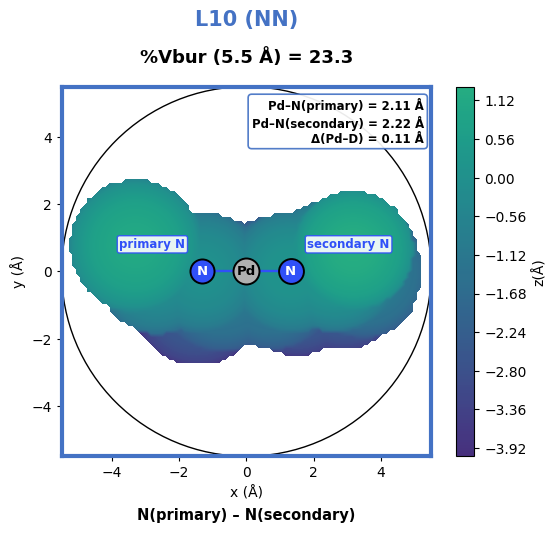

✓ L10  | NN | NORMAL   | primary N = 20 | secondary = N23 | Pd–N = 2.107 Å | Pd–N = 2.218 Å | ΔPd-D = 0.112 Å | %Vbur = 23.26


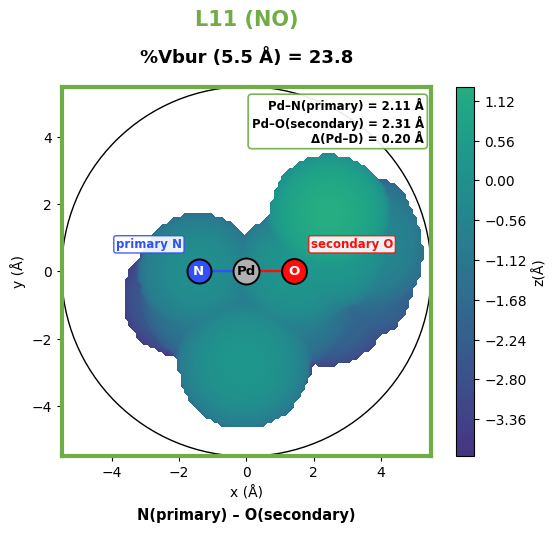

✓ L11  | NO | NORMAL   | primary N = 20 | secondary = O24 | Pd–N = 2.115 Å | Pd–O = 2.311 Å | ΔPd-D = 0.196 Å | %Vbur = 23.82


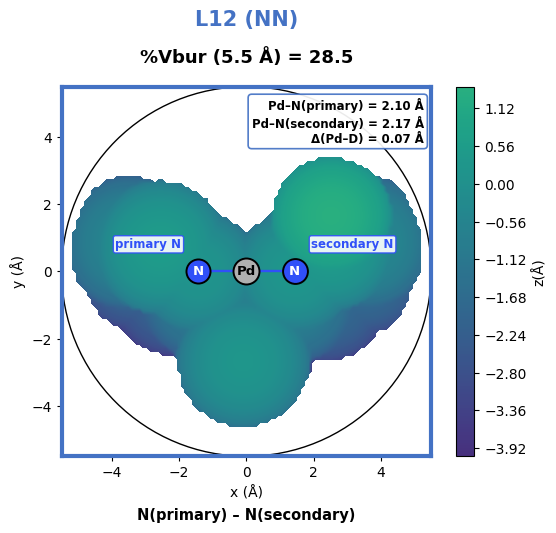

✓ L12  | NN | NORMAL   | primary N = 20 | secondary = N24 | Pd–N = 2.101 Å | Pd–N = 2.168 Å | ΔPd-D = 0.068 Å | %Vbur = 28.48


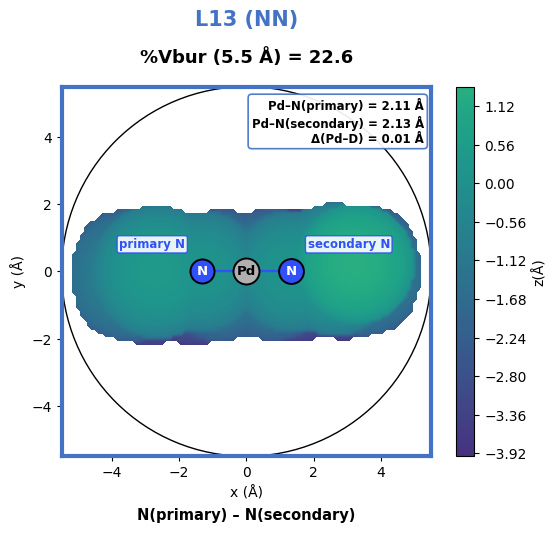

✓ L13  | NN | NORMAL   | primary N = 20 | secondary = N23 | Pd–N = 2.113 Å | Pd–N = 2.127 Å | ΔPd-D = 0.014 Å | %Vbur = 22.59


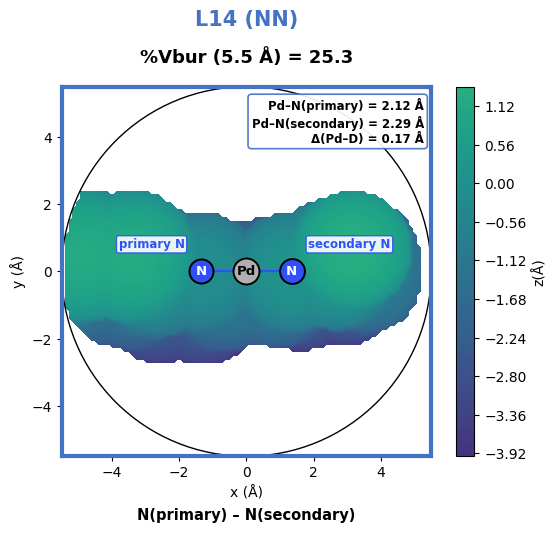

✓ L14  | NN | NORMAL   | primary N = 20 | secondary = N23 | Pd–N = 2.121 Å | Pd–N = 2.286 Å | ΔPd-D = 0.166 Å | %Vbur = 25.29


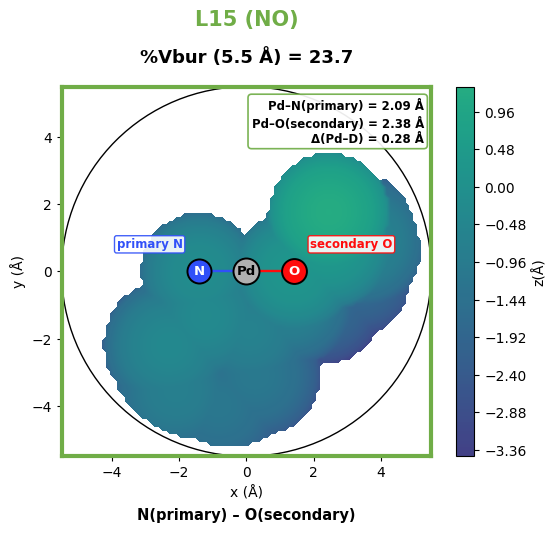

✓ L15  | NO | NORMAL   | primary N = 20 | secondary = O24 | Pd–N = 2.093 Å | Pd–O = 2.377 Å | ΔPd-D = 0.284 Å | %Vbur = 23.70


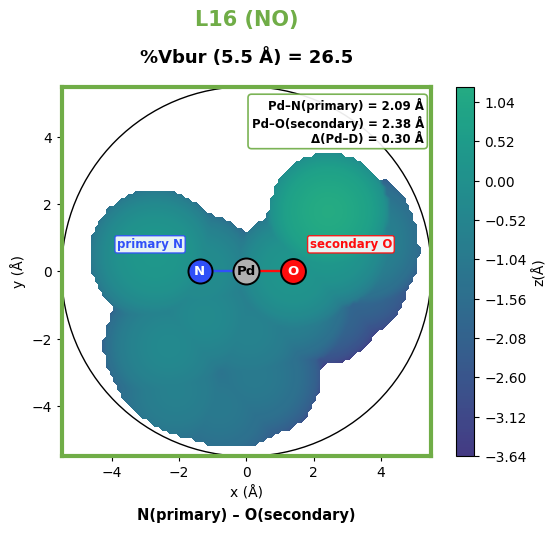

✓ L16  | NO | NORMAL   | primary N = 20 | secondary = O24 | Pd–N = 2.089 Å | Pd–O = 2.385 Å | ΔPd-D = 0.296 Å | %Vbur = 26.51


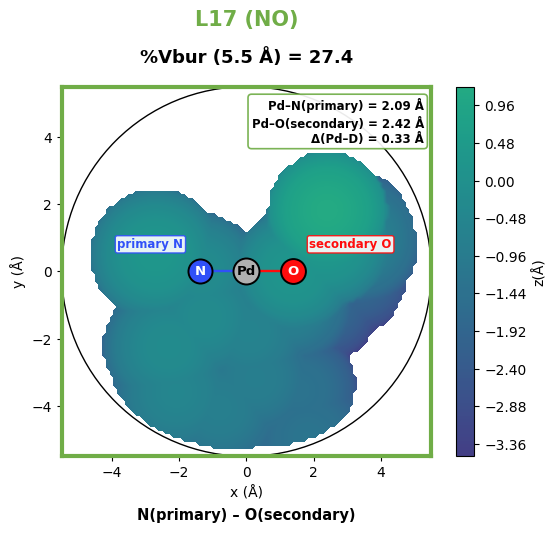

✓ L17  | NO | NORMAL   | primary N = 20 | secondary = O24 | Pd–N = 2.086 Å | Pd–O = 2.416 Å | ΔPd-D = 0.331 Å | %Vbur = 27.43


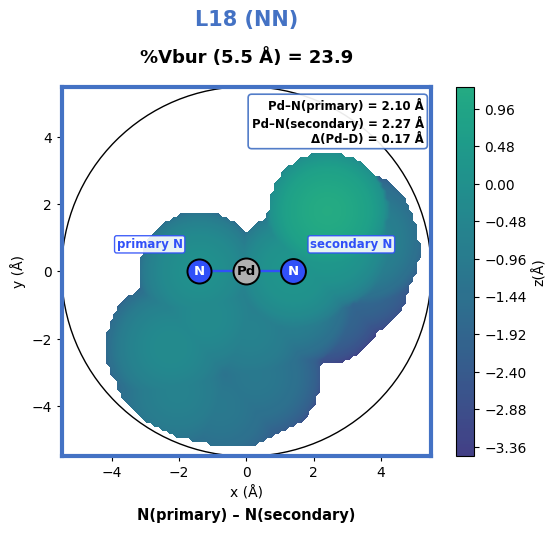

✓ L18  | NN | NORMAL   | primary N = 20 | secondary = N24 | Pd–N = 2.104 Å | Pd–N = 2.275 Å | ΔPd-D = 0.171 Å | %Vbur = 23.93


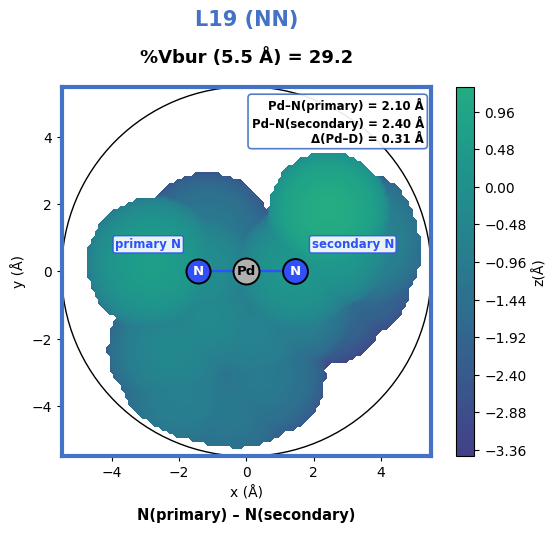

✓ L19  | NN | NORMAL   | primary N = 20 | secondary = N24 | Pd–N = 2.096 Å | Pd–N = 2.401 Å | ΔPd-D = 0.305 Å | %Vbur = 29.17


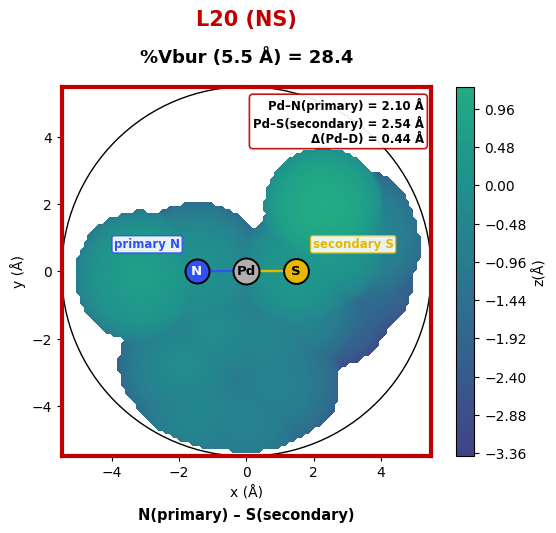

✓ L20  | NS | NORMAL   | primary N = 20 | secondary = S24 | Pd–N = 2.096 Å | Pd–S = 2.540 Å | ΔPd-D = 0.444 Å | %Vbur = 28.36


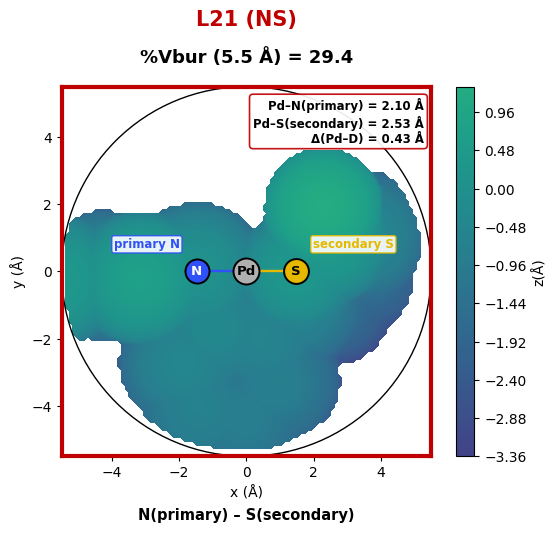

✓ L21  | NS | NORMAL   | primary N = 20 | secondary = S24 | Pd–N = 2.098 Å | Pd–S = 2.526 Å | ΔPd-D = 0.428 Å | %Vbur = 29.39


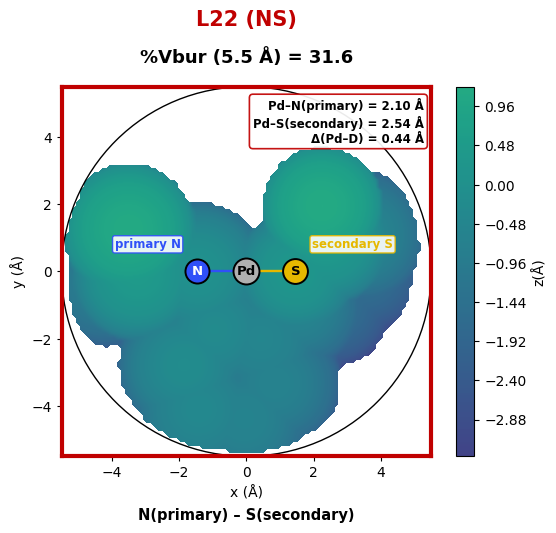

✓ L22  | NS | NORMAL   | primary N = 20 | secondary = S24 | Pd–N = 2.102 Å | Pd–S = 2.539 Å | ΔPd-D = 0.437 Å | %Vbur = 31.56


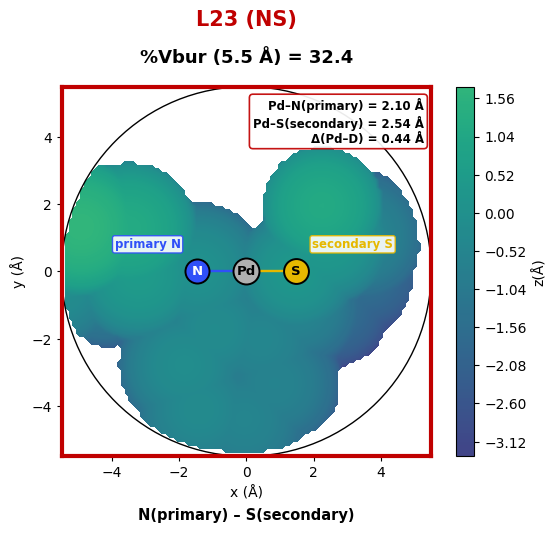

✓ L23  | NS | NORMAL   | primary N = 20 | secondary = S24 | Pd–N = 2.100 Å | Pd–S = 2.544 Å | ΔPd-D = 0.444 Å | %Vbur = 32.44


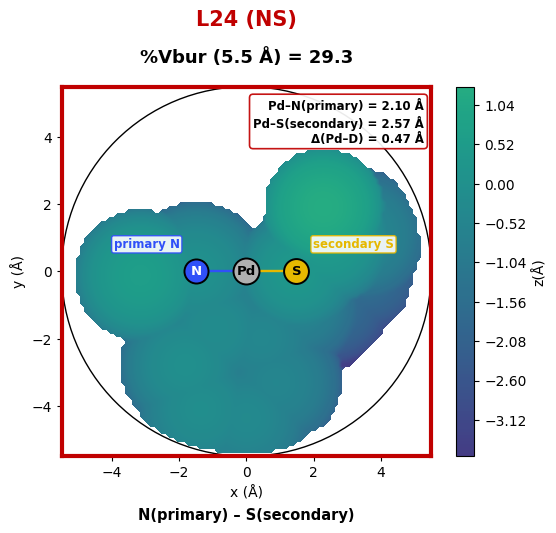

✓ L24  | NS | NORMAL   | primary N = 20 | secondary = S24 | Pd–N = 2.103 Å | Pd–S = 2.569 Å | ΔPd-D = 0.466 Å | %Vbur = 29.32


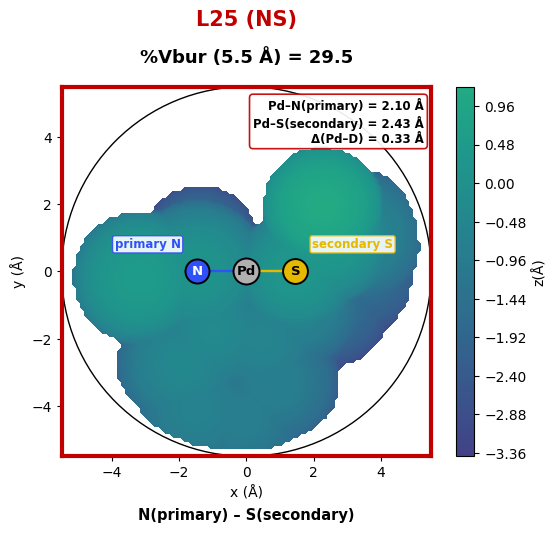

✓ L25  | NS | NORMAL   | primary N = 20 | secondary = S24 | Pd–N = 2.100 Å | Pd–S = 2.432 Å | ΔPd-D = 0.332 Å | %Vbur = 29.51


WORKFLOW COMPLETE
Processed 16 / 16 ligands.


In [26]:
# ============================================================
# COMPLETE NN / NO / NS %VBUR MAP WORKFLOW
# L10–L25
#
# Includes:
#   1. Robust donor detection
#   2. Recovery of L17 and L19
#   3. Rebuild oriented_df
#   4. Morfeus %Vbur map
#   5. Pd + primary N + secondary N/O/S
#   6. Pd–donor distances
#   7. Delta(Pd–D)
#   8. Bold %Vbur
#
# IMPORTANT:
# Keep already-defined:
#   xyz_files
#   LIGAND_CLASSES
#   PD_ATOM
#   LIGAND_START
#   read_xyz_file()
#   calculate_buried_volume()
#   VBUR_FOLDER
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# SETTINGS
# ============================================================

NORMAL_DONOR_CUTOFF = 2.80

# Only used if expected secondary donor is not found normally
FALLBACK_DONOR_CUTOFF = 3.50


# Optional substrate C(beta)
# Keep None until correct atom number is known.
CBETA_ATOM = None


# ============================================================
# COLORS
# ============================================================

CLASS_COLORS = {
    "NN": "#4472C4",    # blue
    "NO": "#70AD47",    # green
    "NS": "#C00000",    # red
}

ATOM_COLORS = {
    "Pd": "#B0B0B0",
    "N":  "#3050F8",
    "O":  "#FF0D0D",
    "S":  "#E6B800",
    "C":  "#404040",
}


# ============================================================
# EXPECTED LIGANDS
# ============================================================

EXPECTED_LIGANDS = [
    "L10", "L11", "L12", "L13",
    "L14", "L15", "L16", "L17",
    "L18", "L19",
    "L20", "L21", "L22",
    "L23", "L24", "L25",
]


# ============================================================
# HELPER — CLEAN LIGAND NAME
# ============================================================

def clean_ligand_name(filepath):

    name = os.path.basename(filepath)

    name = os.path.splitext(name)[0]

    return name


# ============================================================
# HELPER — Pd DISTANCE
# ============================================================

def pd_distance(
    coordinates,
    atom_number
):

    pd_xyz = np.asarray(
        coordinates[PD_ATOM - 1],
        dtype=float
    )

    atom_xyz = np.asarray(
        coordinates[atom_number - 1],
        dtype=float
    )

    return float(
        np.linalg.norm(
            atom_xyz - pd_xyz
        )
    )


# ============================================================
# GET ALL LIGAND N/O/S CANDIDATES
# ============================================================

def get_ligand_donor_candidates(
    elements,
    coordinates
):

    candidates = []

    for atom_number in range(
        LIGAND_START,
        len(elements) + 1
    ):

        element = str(
            elements[atom_number - 1]
        )

        if element not in [
            "N",
            "O",
            "S"
        ]:
            continue

        distance = pd_distance(
            coordinates,
            atom_number
        )

        candidates.append(
            {
                "Atom": atom_number,
                "Element": element,
                "Distance": distance,
            }
        )

    candidates.sort(
        key=lambda x: x["Distance"]
    )

    return candidates


# ============================================================
# ROBUST DONOR SELECTION
#
# Normal cutoff first.
#
# If expected donor is absent:
# NN -> nearest second N
# NO -> nearest O
# NS -> nearest S
#
# This should recover L17 and L19.
# ============================================================

def robust_select_donor_pair(
    ligand,
    ligand_class,
    elements,
    coordinates
):

    candidates = get_ligand_donor_candidates(
        elements,
        coordinates
    )


    normal = [
        x for x in candidates
        if x["Distance"]
        <= NORMAL_DONOR_CUTOFF
    ]


    # ========================================================
    # NN
    # ========================================================

    if ligand_class == "NN":

        normal_N = [
            x for x in normal
            if x["Element"] == "N"
        ]

        if len(normal_N) >= 2:

            return (
                normal_N[0]["Atom"],
                normal_N[1]["Atom"],
                False
            )


        # Fallback
        all_N = [
            x for x in candidates

            if (
                x["Element"] == "N"
                and
                x["Distance"]
                <= FALLBACK_DONOR_CUTOFF
            )
        ]

        if len(all_N) >= 2:

            N1 = all_N[0]
            N2 = all_N[1]

            print(
                f"⚠ {ligand} FALLBACK | "
                f"N{N1['Atom']} = "
                f"{N1['Distance']:.3f} Å | "
                f"N{N2['Atom']} = "
                f"{N2['Distance']:.3f} Å"
            )

            return (
                N1["Atom"],
                N2["Atom"],
                True
            )


    # ========================================================
    # NO
    # ========================================================

    elif ligand_class == "NO":

        normal_N = [
            x for x in normal
            if x["Element"] == "N"
        ]

        normal_O = [
            x for x in normal
            if x["Element"] == "O"
        ]


        if (
            len(normal_N) >= 1
            and
            len(normal_O) >= 1
        ):

            return (
                normal_N[0]["Atom"],
                normal_O[0]["Atom"],
                False
            )


        # Fallback
        all_N = [
            x for x in candidates

            if (
                x["Element"] == "N"
                and
                x["Distance"]
                <= FALLBACK_DONOR_CUTOFF
            )
        ]

        all_O = [
            x for x in candidates

            if (
                x["Element"] == "O"
                and
                x["Distance"]
                <= FALLBACK_DONOR_CUTOFF
            )
        ]


        if (
            len(all_N) >= 1
            and
            len(all_O) >= 1
        ):

            N = all_N[0]
            O = all_O[0]

            print(
                f"⚠ {ligand} FALLBACK | "
                f"N{N['Atom']} = "
                f"{N['Distance']:.3f} Å | "
                f"O{O['Atom']} = "
                f"{O['Distance']:.3f} Å"
            )

            return (
                N["Atom"],
                O["Atom"],
                True
            )


    # ========================================================
    # NS
    # ========================================================

    elif ligand_class == "NS":

        normal_N = [
            x for x in normal
            if x["Element"] == "N"
        ]

        normal_S = [
            x for x in normal
            if x["Element"] == "S"
        ]


        if (
            len(normal_N) >= 1
            and
            len(normal_S) >= 1
        ):

            return (
                normal_N[0]["Atom"],
                normal_S[0]["Atom"],
                False
            )


        # Fallback
        all_N = [
            x for x in candidates

            if (
                x["Element"] == "N"
                and
                x["Distance"]
                <= FALLBACK_DONOR_CUTOFF
            )
        ]

        all_S = [
            x for x in candidates

            if (
                x["Element"] == "S"
                and
                x["Distance"]
                <= FALLBACK_DONOR_CUTOFF
            )
        ]


        if (
            len(all_N) >= 1
            and
            len(all_S) >= 1
        ):

            N = all_N[0]
            S = all_S[0]

            print(
                f"⚠ {ligand} FALLBACK | "
                f"N{N['Atom']} = "
                f"{N['Distance']:.3f} Å | "
                f"S{S['Atom']} = "
                f"{S['Distance']:.3f} Å"
            )

            return (
                N["Atom"],
                S["Atom"],
                True
            )


    # ========================================================
    # FAILED
    # ========================================================

    print(
        f"\n✗ {ligand}: "
        f"could not identify "
        f"{ligand_class} donor pair."
    )

    print(
        "Available ligand N/O/S atoms:"
    )

    for x in candidates:

        print(
            f"   {x['Element']}"
            f"{x['Atom']} = "
            f"{x['Distance']:.3f} Å"
        )

    return None


# ============================================================
# BUILD oriented_df AGAIN
# ============================================================

oriented_records = []


print("\n")
print("=" * 75)
print("DONOR DETECTION")
print("=" * 75)


for filepath in xyz_files:

    ligand = clean_ligand_name(
        filepath
    )


    # Only L10-L25 used here
    if ligand not in EXPECTED_LIGANDS:
        continue


    ligand_class = LIGAND_CLASSES[
        ligand
    ]


    elements, coordinates = read_xyz_file(
        filepath
    )


    pair = robust_select_donor_pair(
        ligand=ligand,
        ligand_class=ligand_class,
        elements=elements,
        coordinates=coordinates
    )


    if pair is None:

        print(
            f"SKIPPING {ligand}"
        )

        continue


    donor1, donor2, used_fallback = pair


    d1_element = str(
        elements[donor1 - 1]
    )

    d2_element = str(
        elements[donor2 - 1]
    )


    d1_distance = pd_distance(
        coordinates,
        donor1
    )

    d2_distance = pd_distance(
        coordinates,
        donor2
    )


    oriented_records.append(
        {
            "Ligand": ligand,
            "Class": ligand_class,
            "File": filepath,

            "Donor1": donor1,
            "Donor2": donor2,

            "Donor1_Element":
                d1_element,

            "Donor2_Element":
                d2_element,

            "Pd_Donor1_A":
                d1_distance,

            "Pd_Donor2_A":
                d2_distance,

            "FallbackDonorSelection":
                used_fallback,
        }
    )


# ============================================================
# CREATE DATAFRAME
# ============================================================

oriented_df = pd.DataFrame(
    oriented_records
)


# Correct ligand order
oriented_df["Ligand_Order"] = (
    oriented_df["Ligand"]
    .str.replace(
        "L",
        "",
        regex=False
    )
    .astype(int)
)


oriented_df = (
    oriented_df
    .sort_values(
        "Ligand_Order"
    )
    .drop(
        columns="Ligand_Order"
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# CHECK THAT ALL 16 ARE PRESENT
# ============================================================

present = set(
    oriented_df["Ligand"]
)

missing = [
    lig
    for lig in EXPECTED_LIGANDS
    if lig not in present
]


print("\n")
print("=" * 75)
print("DONOR-DETECTION SUMMARY")
print("=" * 75)

print(
    f"Expected ligands : "
    f"{len(EXPECTED_LIGANDS)}"
)

print(
    f"Detected ligands : "
    f"{len(oriented_df)}"
)

print(
    "Missing ligands  :",
    missing if missing else "NONE"
)


print("\nSelected donors:\n")

display(
    oriented_df[
        [
            "Ligand",
            "Class",
            "Donor1",
            "Donor1_Element",
            "Pd_Donor1_A",
            "Donor2",
            "Donor2_Element",
            "Pd_Donor2_A",
            "FallbackDonorSelection",
        ]
    ].round(3)
)


# ============================================================
# STOP HERE IF SOMETHING IS STILL MISSING
# ============================================================

if missing:

    raise RuntimeError(
        "Some ligands are still missing. "
        "Inspect donor candidates above "
        "before generating maps."
    )


# ============================================================
# VECTOR NORMALIZATION
# ============================================================

def normalize_vector(v):

    v = np.asarray(
        v,
        dtype=float
    )

    norm = np.linalg.norm(v)

    if norm < 1.0e-12:

        raise ValueError(
            "Zero-length vector."
        )

    return v / norm


# ============================================================
# IDENTIFY SECONDARY DONOR
# ============================================================

def get_secondary_donor(
    elements,
    donor1,
    donor2,
    ligand_class
):

    donor1 = int(donor1)
    donor2 = int(donor2)

    e1 = str(
        elements[donor1 - 1]
    )

    e2 = str(
        elements[donor2 - 1]
    )


    # NO -> O secondary
    if ligand_class == "NO":

        if e1 == "O":
            return donor1, "O"

        if e2 == "O":
            return donor2, "O"


    # NS -> S secondary
    if ligand_class == "NS":

        if e1 == "S":
            return donor1, "S"

        if e2 == "S":
            return donor2, "S"


    # NN -> current convention:
    # donor2 = secondary N
    if ligand_class == "NN":

        if (
            e1 == "N"
            and
            e2 == "N"
        ):

            return donor2, "N"


    raise ValueError(
        f"Could not identify secondary donor "
        f"for {ligand_class}."
    )


# ============================================================
# PRIMARY DONOR
# ============================================================

def get_primary_donor(
    donor1,
    donor2,
    secondary_atom
):

    if secondary_atom == donor1:
        return donor2

    return donor1


# ============================================================
# COMMON MAP COORDINATE SYSTEM
# ============================================================

def transform_to_map_coordinates(
    coordinates,
    pd_atom,
    donor1,
    donor2
):

    xyz = np.asarray(
        coordinates,
        dtype=float
    ).copy()


    # Pd at origin
    pd_xyz = xyz[
        pd_atom - 1
    ].copy()

    xyz = xyz - pd_xyz


    d1 = xyz[
        donor1 - 1
    ]

    d2 = xyz[
        donor2 - 1
    ]


    # Z axis:
    # Pd -> donor midpoint
    midpoint = (
        d1 + d2
    ) / 2.0


    z_axis = normalize_vector(
        midpoint
    )


    # X axis:
    # donor separation projected
    # perpendicular to Z
    difference = (
        d2 - d1
    )


    x_temp = (

        difference

        -

        np.dot(
            difference,
            z_axis
        )
        *
        z_axis
    )


    x_axis = normalize_vector(
        x_temp
    )


    # Y axis
    y_axis = normalize_vector(

        np.cross(
            z_axis,
            x_axis
        )
    )


    # Recalculate X
    x_axis = normalize_vector(

        np.cross(
            y_axis,
            z_axis
        )
    )


    rotation = np.vstack(
        [
            x_axis,
            y_axis,
            z_axis
        ]
    )


    transformed = (

        rotation

        @ xyz.T

    ).T


    return transformed


# ============================================================
# MAP X/Y POSITION
# ============================================================

def get_map_xy(
    map_coordinates,
    atom_number
):

    xyz = map_coordinates[
        int(atom_number) - 1
    ]

    return (
        float(xyz[0]),
        float(xyz[1])
    )


# ============================================================
# DRAW ATOM
# ============================================================

def draw_map_atom(
    ax,
    x,
    y,
    label,
    color,
    size=300
):

    ax.scatter(

        x,
        y,

        s=size,

        facecolor=color,

        edgecolor="black",

        linewidth=1.4,

        zorder=60
    )


    if label in [
        "Pd",
        "S",
        "Cβ"
    ]:

        text_color = "black"

    else:

        text_color = "white"


    ax.text(

        x,
        y,

        label,

        ha="center",
        va="center",

        fontsize=9.5,

        fontweight="bold",

        color=text_color,

        zorder=61
    )


# ============================================================
# GENERATE ALL 16 MAPS
# ============================================================

print("\n")
print("=" * 75)
print("GENERATING %VBUR MAPS")
print("=" * 75)


for _, row in oriented_df.iterrows():


    ligand = str(
        row["Ligand"]
    )

    ligand_class = str(
        row["Class"]
    )

    donor1 = int(
        row["Donor1"]
    )

    donor2 = int(
        row["Donor2"]
    )


    elements, coordinates = read_xyz_file(
        row["File"]
    )


    try:

        # ====================================================
        # BURIED VOLUME
        # ====================================================

        bv = calculate_buried_volume(

            elements=elements,

            coordinates=coordinates,

            donor1=donor1,

            donor2=donor2
        )


        percent_vbur = (

            bv.fraction_buried_volume

            * 100.0
        )


        # ====================================================
        # PRIMARY / SECONDARY DONOR
        # ====================================================

        secondary_atom, secondary_element = (
            get_secondary_donor(

                elements,

                donor1,

                donor2,

                ligand_class
            )
        )


        primary_atom = get_primary_donor(

            donor1,

            donor2,

            secondary_atom
        )


        # ====================================================
        # TRUE 3D DISTANCES
        # ====================================================

        pd_primary_distance = pd_distance(

            coordinates,

            primary_atom
        )


        pd_secondary_distance = pd_distance(

            coordinates,

            secondary_atom
        )


        delta_pd_donor = abs(

            pd_secondary_distance

            -

            pd_primary_distance
        )


        # ====================================================
        # MAP COORDINATES
        # ====================================================

        map_coordinates = (
            transform_to_map_coordinates(

                coordinates,

                PD_ATOM,

                donor1,

                donor2
            )
        )


        primary_x, primary_y = (
            get_map_xy(

                map_coordinates,

                primary_atom
            )
        )


        secondary_x, secondary_y = (
            get_map_xy(

                map_coordinates,

                secondary_atom
            )
        )


        # Pd = map origin
        pd_x = 0.0
        pd_y = 0.0


        # ====================================================
        # OPTIONAL Cβ
        # ====================================================

        if CBETA_ATOM is not None:

            cbeta_x, cbeta_y = (
                get_map_xy(

                    map_coordinates,

                    CBETA_ATOM
                )
            )


        # ====================================================
        # CAPTURE MORFEUS FIGURE
        # ====================================================

        original_show = plt.show


        plt.show = (
            lambda *args, **kwargs: None
        )


        try:

            # SAME colormap for all classes
            bv.plot_steric_map(
                cmap="viridis"
            )

        finally:

            plt.show = original_show


        figure_numbers = (
            plt.get_fignums()
        )


        if not figure_numbers:

            raise RuntimeError(
                "Could not capture Morfeus figure."
            )


        fig = plt.figure(
            figure_numbers[-1]
        )


        axes = fig.get_axes()


        if not axes:

            raise RuntimeError(
                "No axes in Morfeus figure."
            )


        # Largest axis = map
        main_ax = max(

            axes,

            key=lambda a:

                a.get_position().width

                *

                a.get_position().height
        )


        # ====================================================
        # CLASS FRAME
        # ====================================================

        class_color = CLASS_COLORS[
            ligand_class
        ]


        for spine in (
            main_ax.spines.values()
        ):

            spine.set_visible(True)

            spine.set_color(
                class_color
            )

            spine.set_linewidth(
                3.0
            )


        # ====================================================
        # DRAW BOND GUIDES FIRST
        # ====================================================

        main_ax.plot(

            [pd_x, primary_x],

            [pd_y, primary_y],

            color=ATOM_COLORS["N"],

            linewidth=1.7,

            zorder=50
        )


        main_ax.plot(

            [pd_x, secondary_x],

            [pd_y, secondary_y],

            color=ATOM_COLORS[
                secondary_element
            ],

            linewidth=1.7,

            zorder=50
        )


        # ====================================================
        # Pd
        # ====================================================

        draw_map_atom(

            main_ax,

            pd_x,
            pd_y,

            "Pd",

            ATOM_COLORS["Pd"],

            size=350
        )


        # ====================================================
        # PRIMARY N
        # ====================================================

        draw_map_atom(

            main_ax,

            primary_x,
            primary_y,

            "N",

            ATOM_COLORS["N"],

            size=300
        )


        # ====================================================
        # SECONDARY N / O / S
        # ====================================================

        draw_map_atom(

            main_ax,

            secondary_x,
            secondary_y,

            secondary_element,

            ATOM_COLORS[
                secondary_element
            ],

            size=320
        )


        # ====================================================
        # PRIMARY LABEL
        # ====================================================

        main_ax.annotate(

            "primary N",

            xy=(
                primary_x,
                primary_y
            ),

            xytext=(
                -12,
                17
            ),

            textcoords="offset points",

            ha="right",

            fontsize=8.5,

            fontweight="bold",

            color=ATOM_COLORS["N"],

            bbox={
                "boxstyle":
                    "round,pad=0.18",

                "facecolor":
                    "white",

                "edgecolor":
                    ATOM_COLORS["N"],

                "alpha":
                    0.90
            },

            zorder=70
        )


        # ====================================================
        # SECONDARY LABEL
        # ====================================================

        main_ax.annotate(

            f"secondary "
            f"{secondary_element}",

            xy=(
                secondary_x,
                secondary_y
            ),

            xytext=(
                12,
                17
            ),

            textcoords="offset points",

            ha="left",

            fontsize=8.5,

            fontweight="bold",

            color=ATOM_COLORS[
                secondary_element
            ],

            bbox={
                "boxstyle":
                    "round,pad=0.18",

                "facecolor":
                    "white",

                "edgecolor":
                    ATOM_COLORS[
                        secondary_element
                    ],

                "alpha":
                    0.90
            },

            zorder=70
        )


        # ====================================================
        # OPTIONAL SUBSTRATE Cβ
        # ====================================================

        if CBETA_ATOM is not None:

            main_ax.plot(

                [pd_x, cbeta_x],

                [pd_y, cbeta_y],

                color=ATOM_COLORS["C"],

                linewidth=1.4,

                linestyle="--",

                zorder=49
            )


            draw_map_atom(

                main_ax,

                cbeta_x,
                cbeta_y,

                "Cβ",

                ATOM_COLORS["C"],

                size=300
            )


            main_ax.annotate(

                "substrate",

                xy=(
                    cbeta_x,
                    cbeta_y
                ),

                xytext=(
                    0,
                    17
                ),

                textcoords="offset points",

                ha="center",

                fontsize=8.5,

                fontweight="bold",

                color=ATOM_COLORS["C"]
            )


        # ====================================================
        # TITLE
        # ====================================================

        main_ax.set_title(

            f"{ligand} "
            f"({ligand_class})",

            fontsize=15,

            fontweight="bold",

            color=class_color,

            pad=44
        )


        # ====================================================
        # BOLD %VBUR
        # ====================================================

        main_ax.text(

            0.50,
            1.055,

            f"%Vbur (5.5 Å) = "
            f"{percent_vbur:.1f}",

            transform=main_ax.transAxes,

            ha="center",
            va="bottom",

            fontsize=13,

            fontweight="bold",

            color="black",

            clip_on=False
        )


        # ====================================================
        # COORDINATION BOX
        # ====================================================

        coordination_text = (

            f"Pd–N(primary) = "
            f"{pd_primary_distance:.2f} Å\n"

            f"Pd–{secondary_element}"
            f"(secondary) = "
            f"{pd_secondary_distance:.2f} Å\n"

            f"Δ(Pd–D) = "
            f"{delta_pd_donor:.2f} Å"
        )


        main_ax.text(

            0.98,
            0.97,

            coordination_text,

            transform=main_ax.transAxes,

            ha="right",
            va="top",

            fontsize=8.5,

            fontweight="bold",

            color="black",

            bbox={
                "boxstyle":
                    "round,pad=0.30",

                "facecolor":
                    "white",

                "edgecolor":
                    class_color,

                "linewidth":
                    1.2,

                "alpha":
                    0.92
            },

            zorder=80
        )


        # ====================================================
        # BOTTOM LABEL
        # ====================================================

        main_ax.text(

            0.50,
            -0.14,

            f"N(primary) – "
            f"{secondary_element}"
            f"(secondary)",

            transform=main_ax.transAxes,

            ha="center",
            va="top",

            fontsize=10.5,

            fontweight="bold",

            color="black",

            clip_on=False
        )


        # ====================================================
        # SAVE
        # ====================================================

        output_png = os.path.join(

            VBUR_FOLDER,

            f"{ligand}_"
            f"{ligand_class}_"
            f"Vbur_5.5A_"
            f"Pd_Donors.png"
        )


        fig.savefig(

            output_png,

            dpi=600,

            bbox_inches="tight",

            facecolor="white"
        )


        # ====================================================
        # DISPLAY ONCE
        # ====================================================

        original_show()


        # ====================================================
        # CLOSE
        # ====================================================

        plt.close(fig)


        # ====================================================
        # PRINT
        # ====================================================

        fallback_text = (

            "FALLBACK"

            if bool(
                row[
                    "FallbackDonorSelection"
                ]
            )

            else

            "NORMAL"
        )


        print(

            f"✓ {ligand:4s} | "

            f"{ligand_class:2s} | "

            f"{fallback_text:8s} | "

            f"primary N = "
            f"{primary_atom} | "

            f"secondary = "
            f"{secondary_element}"
            f"{secondary_atom} | "

            f"Pd–N = "
            f"{pd_primary_distance:.3f} Å | "

            f"Pd–{secondary_element} = "
            f"{pd_secondary_distance:.3f} Å | "

            f"ΔPd-D = "
            f"{delta_pd_donor:.3f} Å | "

            f"%Vbur = "
            f"{percent_vbur:.2f}"
        )


    except Exception as error:

        if "original_show" in locals():

            plt.show = original_show


        plt.close("all")


        print(

            f"MAP ERROR: "
            f"{ligand}: "
            f"{error}"
        )


# ============================================================
# FINAL CHECK
# ============================================================

print("\n")
print("=" * 75)
print("WORKFLOW COMPLETE")
print("=" * 75)

print(
    f"Processed "
    f"{len(oriented_df)} / "
    f"{len(EXPECTED_LIGANDS)} "
    f"ligands."
)